# ICA Project — Experimental Notebook

**Course project:** Independent Component Analysis (ICA) for dimensionality reduction and source separation  

This notebook is organized as a compact experimental report:

- **Part 1:** comparison of ICA solvers on synthetic mixtures with known ground truth;
- **Part 2:** ICA under missing data, including synthetic experiments and transfer to real EEG;
- **Conclusion:** final takeaways, limitations, and report-ready discussion points.

---

## Table of Contents

1. [Global setup](#Global-setup)
2. [Part 1 — Synthetic ICA benchmark](#Part-1-—-Synthetic-ICA-benchmark)
   1. [Algorithms and mathematical background](#Algorithms-and-mathematical-background)
   2. [Experimental protocol](#Experiment-protocol)
   3. [Low-dimensional benchmark (d = 4 to 9)](#Low-dimensional-comparison-(4-to-9))
   4. [Scalability benchmark (d = 10 to 100)](#Scalability-analysis-(10-to-100))
   5. [Sensitivity analyses](#Sensitivity-analyses)
   6. [Part 1 summary](#Part-1-summary)
3. [Part 2 — ICA with missing data](#Part-2-—-ICA-with-missing-data)
   1. [Problem setup and workflow](#Task-and-protocol)
   2. [Missing-data preprocessing utilities](#Missing-data-utilities)
   3. [Missing-data solver variants](#Missing-data-solver-variants)
   4. [Synthetic benchmark under missing data](#Synthetic-benchmark-under-missing-data)
   5. [Single-case synthetic illustration](#Single-case-synthetic-illustration)
   6. [Missing-rate sensitivity study](#Impact-of-the-missing-rate)
   7. [EEG transfer study](#EEG-transfer-study)
4. [Conclusion](#Conclusion)


<a id="Global-setup"></a>

## Global setup

**Task.** Load all required packages, define numerical hyperparameters, and implement shared utilities used throughout the notebook.

**Implementation principles.**

- Keep every experiment reproducible through explicit random seeds.
- Work with data in shape `(n_channels, n_samples)`.
- Separate reusable numerical primitives from experiment code.
- Use a consistent notation: observed mixtures are denoted by $X$, sources by $S$, mixing matrix by $A$, and unmixing matrix by $W$.

**What this section contains.**

- Utility functions for reproducibility, source standardization, symmetric orthogonalization, gradient clipping, and convergence checking.
- Preprocessing functions for centering and whitening the observed mixtures.
- Core ICA ingredients, including the Infomax objective, its gradient, the natural gradient direction, and the Amari index for evaluation.
- Synthetic data generation functions that create independent non-Gaussian sources and mix them through a full-rank matrix $A$ to produce the observations:
\[
X = AS.
\]

**Purpose.** This section provides the common mathematical and computational tools used by all ICA experiments in Part 1 and Part 2.


In [ ]:
import time, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

warnings.filterwarnings("ignore")

try:
    from sklearn.decomposition import FastICA
    SKLEARN_AVAILABLE = True
except Exception:
    SKLEARN_AVAILABLE = False

SEED = 42
N_SAMPLES = 1000
MAX_ITER = 1000
BATCH_SIZE = 128
LR_BATCH = 0.03
LR_SGD = 0.01
LR_ADAM = 0.008
LR_NATURAL = 0.02
TOLERANCE = 1e-6
PATIENCE = 20
GRADIENT_CLIP = 5.0
EPS = 1e-10

np.random.seed(SEED)

@dataclass
class ICAResult:
    name: str
    W: np.ndarray
    Y: np.ndarray
    costs: List[float]
    n_iter: int
    elapsed: float

def set_seed(seed: int) -> None:
    np.random.seed(seed)

def standardize_rows(S: np.ndarray) -> np.ndarray:
    S = S - S.mean(axis=1, keepdims=True)
    S = S / (S.std(axis=1, keepdims=True) + EPS)
    return S

def symmetric_orthogonalization(W: np.ndarray) -> np.ndarray:
    U, s, Vt = np.linalg.svd(W, full_matrices=False)
    return U @ Vt

def clip_grad(G: np.ndarray, clip_value: float = GRADIENT_CLIP) -> np.ndarray:
    norm = np.linalg.norm(G)
    if norm > clip_value: G = G * (clip_value / (norm + EPS))
    return G

def has_converged(costs: List[float], tol: float = TOLERANCE, patience: int = PATIENCE) -> bool:
    if len(costs) < patience + 1: return False
    recent = np.abs(np.diff(costs[-(patience + 1):]))
    return np.all(recent < tol)

def preprocess(X: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Center + whiten
    X: shape (n_features, n_samples)
    Returns:
        X_white, whitening_matrix, mean_vector
    """
    mean_vec = X.mean(axis=1, keepdims=True)
    Xc = X - mean_vec
    cov = (Xc @ Xc.T) / Xc.shape[1]
    eigvals, eigvecs = np.linalg.eigh(cov)
    idx = np.argsort(eigvals)[::-1]
    eigvals, eigvecs = eigvals[idx], eigvecs[:, idx]
    whitening = np.diag(1.0 / np.sqrt(eigvals + EPS)) @ eigvecs.T
    X_white = whitening @ Xc
    return X_white, whitening, mean_vec

def infomax_objective(W: np.ndarray, X: np.ndarray) -> float:
    """
    Minimize negative log-likelihood up to constants:
    J(W) = -log|det(W)| + E[ log cosh(Wx) ]
    """
    Y = W @ X
    sign, logabsdet = np.linalg.slogdet(W)
    if sign == 0: return np.inf
    return -logabsdet + np.mean(np.log(np.cosh(Y) + EPS))

def infomax_gradient(W: np.ndarray, X_batch: np.ndarray) -> np.ndarray:
    """
    Gradient of the objective above.
    """
    n_features = W.shape[0]
    Y = W @ X_batch
    score = np.tanh(Y)
    inv_wt = np.linalg.inv(W.T + EPS * np.eye(n_features))
    grad = -inv_wt + (score @ X_batch.T) / X_batch.shape[1]
    return grad

def natural_gradient_direction(W: np.ndarray, X_batch: np.ndarray) -> np.ndarray:
    """
    Relative / natural gradient direction for minimizing objective:
    grad_nat = [ -I + E[g(y) y^T] ] W
    with g(y)=tanh(y)
    """
    n_features = W.shape[0]
    Y = W @ X_batch
    rel = -np.eye(n_features) + (np.tanh(Y) @ Y.T) / X_batch.shape[1]
    return rel @ W

def amari_index(W_est: np.ndarray, A_true: np.ndarray) -> float:
    """
    Uses C = W_est @ A_true.
    0 means perfect separation up to permutation and scaling.
    """
    C = np.abs(W_est @ A_true)
    n = C.shape[0]
    row_term = np.sum(np.sum(C, axis=1) / (np.max(C, axis=1) + EPS) - 1.0)
    col_term = np.sum(np.sum(C, axis=0) / (np.max(C, axis=0) + EPS) - 1.0)
    return (row_term + col_term) / (2.0 * n * (n - 1) + EPS)

def align_sources(Y: np.ndarray, S_true: np.ndarray) -> np.ndarray:
    """
    Simple greedy sign alignment for plotting only.
    """
    Y_aligned = Y.copy()
    for i in range(min(Y.shape[0], S_true.shape[0])):
        corr = np.corrcoef(Y_aligned[i], S_true[i])[0, 1]
        if np.isnan(corr): corr = 0.0
        if corr < 0: Y_aligned[i] *= -1
    return Y_aligned

def generate_sources(n_sources: int, n_samples: int = N_SAMPLES, seed: int = SEED) -> np.ndarray:
    """
    Mixture of deterministic and non-Gaussian stochastic sources.
    Includes super-Gaussian and sub-Gaussian components.
    """
    rng = np.random.default_rng(seed)
    t = np.linspace(0, 1, n_samples)
    sources = []
    for i in range(n_sources):
        mode = i % 10
        freq = rng.uniform(3, 18)
        phase = rng.uniform(0, 2 * np.pi)
        if mode == 0: s = np.sin(2 * np.pi * freq * t + phase)
        elif mode == 1: s = np.sign(np.sin(2 * np.pi * freq * t + phase))
        elif mode == 2: s = 2 * (freq * t - np.floor(0.5 + freq * t))
        elif mode == 3: s = np.sin(2 * np.pi * (freq * t + 10 * t**2))
        elif mode == 4: s = rng.laplace(0, 1, n_samples)
        elif mode == 5: s = rng.logistic(0, 1, n_samples)
        elif mode == 6: s = rng.uniform(-1, 1, n_samples)
        elif mode == 7: s = rng.standard_t(df=5, size=n_samples)
        elif mode == 8: s = np.sin(2 * np.pi * 2 * t) * np.sin(2 * np.pi * freq * t)
        else:
            s = np.zeros(n_samples)
            impulse_idx = np.arange(0, n_samples, max(10, int(n_samples / (freq * 20 + 1))))
            s[impulse_idx] = 1.0
        s = s + 1e-6 * rng.standard_normal(n_samples)
        sources.append(s)
    S = np.vstack(sources)
    return standardize_rows(S)

def generate_mixture(n_sources: int, n_samples: int = N_SAMPLES, seed: int = SEED) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    rng = np.random.default_rng(seed)
    S = generate_sources(n_sources=n_sources, n_samples=n_samples, seed=seed)
    A = rng.uniform(0.5, 2.0, size=(n_sources, n_sources))
    while np.linalg.matrix_rank(A) < n_sources: A = rng.uniform(0.5, 2.0, size=(n_sources, n_sources))
    X = A @ S
    return S, A, X

<a id="Part-1-—-Synthetic-ICA-benchmark"></a>

## Part 1 — Synthetic ICA benchmark

**Task.** Compare several ICA solvers on synthetic mixtures where the ground-truth mixing matrix is known. The main questions are:

1. Which method best recovers the sources in **low dimensions**?
2. How do quality and runtime evolve as the dimension grows from **10 to 100**?
3. How do deterministic and stochastic optimization strategies compare?

<a id="Algorithms-and-mathematical-background"></a>

### Algorithms and mathematical background

We assume the standard ICA model
$$X = AS,$$
where:
- $S \in \mathbb{R}^{d \times n}$ contains mutually independent sources,
- $A \in \mathbb{R}^{d \times d}$ is an unknown invertible mixing matrix,
- $X \in \mathbb{R}^{d \times n}$ is the observed mixture.

After centering and whitening, we estimate an unmixing matrix $W$ such that
$$Y = WX$$
approximates the independent sources.

The notebook implements the following method families:

### 1. FastICA
FastICA uses a fixed-point update for a contrast based on non-Gaussianity. With $g(u)=\tanh(u)$, a symmetric update has the form
$$W_{\text{new}} = \frac{1}{n} g(WX)X^\top - \operatorname{diag}\!\left(\mathbb{E}[g'(WX)]\right)W,$$
followed by symmetric orthogonalization.

### 2. Infomax (batch, SGD, Adam)
The optimization objective used here is the negative log-likelihood surrogate
$$J(W) = -\log |\det(W)| + \mathbb{E}[\log \cosh(WX)].$$
Its gradient is used in three optimization modes:
- **batch gradient descent**;
- **mini-batch SGD**;
- **Adam**, which adds first- and second-moment adaptation.

### 3. Natural-gradient ICA
The natural-gradient update uses the information geometry of the ICA model. A standard relative-gradient form is
$$W \leftarrow W - \eta \left(-I + \frac{1}{n}\tanh(Y)Y^\top\right)W,$$
which often improves stability in higher dimensions.

### 4. Orthogonalized variants
Some solvers optionally project the iterate back to the orthogonal group after each update. This enforces numerical stability after whitening, but it can also alter the optimization path.


In [ ]:
# =========================
# Algorithms
# =========================
def fastica_baseline(X_white: np.ndarray, random_state: int = SEED, max_iter: int = MAX_ITER) -> ICAResult:
    if not SKLEARN_AVAILABLE: raise ImportError("scikit-learn is required for FastICA baseline.")
    start = time.time()
    ica = FastICA(n_components=X_white.shape[0], whiten=False, max_iter=max_iter, tol=1e-4, random_state=random_state)
    S_est = ica.fit_transform(X_white.T).T
    W_est = ica.components_
    costs = []
    elapsed = time.time() - start
    return ICAResult(name="FastICA", W=W_est, Y=S_est, costs=costs, n_iter=int(getattr(ica, "n_iter_", max_iter)), elapsed=elapsed)

def fastica_scratch(X_white, random_state: int = SEED, max_iter=500, tol=1e-6):
    set_seed(random_state)
    start_time = time.time()
    n_features, n_samples = X_white.shape
    W = np.random.randn(n_features, n_features)
    W = symmetric_orthogonalization(W)
    for i in range(max_iter):
        WX = W @ X_white
        g = np.tanh(WX)
        g_prime = 1 - g**2
        W_new = (g @ X_white.T) / n_samples - np.diag(g_prime.mean(axis=1)) @ W
        W_new = symmetric_orthogonalization(W_new)
        diff = np.max(np.abs(np.abs(np.diag(W_new @ W.T)) - 1))
        W = W_new
        if diff < tol: break
    Y = W @ X_white
    elapsed_time = time.time() - start_time
    return ICAResult(name="FastICA_scratch", W=W, Y=Y, costs=[], n_iter=i + 1, elapsed=elapsed_time)

def batch_infomax(X_white: np.ndarray, lr: float = LR_BATCH, max_iter: int = MAX_ITER, orthogonalize: bool = False, random_state: int = SEED) -> ICAResult:
    set_seed(random_state)
    n_features = X_white.shape[0]
    W = np.eye(n_features) + 0.01 * np.random.randn(n_features, n_features)
    costs = []
    start = time.time()
    for it in range(max_iter):
        grad = infomax_gradient(W, X_white)
        grad = clip_grad(grad)
        W = W - lr * grad
        if orthogonalize: W = symmetric_orthogonalization(W)
        cost = infomax_objective(W, X_white)
        costs.append(cost)
        if np.isnan(cost) or np.isinf(cost): break
        if has_converged(costs): break
    elapsed = time.time() - start
    Y = W @ X_white
    return ICAResult(name=f"Batch{' + Ortho' if orthogonalize else ''}", W=W, Y=Y, costs=costs, n_iter=len(costs), elapsed=elapsed)

def sgd_infomax(X_white: np.ndarray, lr: float = LR_SGD, batch_size: int = BATCH_SIZE, max_iter: int = MAX_ITER, orthogonalize: bool = False, random_state: int = SEED) -> ICAResult:
    set_seed(random_state)
    n_features, n_samples = X_white.shape
    W = np.eye(n_features) + 0.01 * np.random.randn(n_features, n_features)
    costs = []
    start = time.time()
    for it in range(max_iter):
        idx = np.random.choice(n_samples, size=min(batch_size, n_samples), replace=False)
        Xb = X_white[:, idx]
        grad = infomax_gradient(W, Xb)
        grad = clip_grad(grad)
        W = W - lr * grad
        if orthogonalize: W = symmetric_orthogonalization(W)
        cost = infomax_objective(W, X_white)
        costs.append(cost)
        if np.isnan(cost) or np.isinf(cost): break
        if has_converged(costs): break
    elapsed = time.time() - start
    Y = W @ X_white
    return ICAResult(name=f"SGD{' + Ortho' if orthogonalize else ''}", W=W, Y=Y, costs=costs, n_iter=len(costs), elapsed=elapsed)

def adam_infomax(X_white: np.ndarray, lr: float = LR_ADAM, batch_size: int = BATCH_SIZE, beta1: float = 0.9, beta2: float = 0.999, max_iter: int = MAX_ITER, orthogonalize: bool = False, random_state: int = SEED) -> ICAResult:
    set_seed(random_state)
    n_features, n_samples = X_white.shape
    W = np.eye(n_features) + 0.01 * np.random.randn(n_features, n_features)
    m = np.zeros_like(W)
    v = np.zeros_like(W)
    costs = []
    start = time.time()
    for it in range(1, max_iter + 1):
        idx = np.random.choice(n_samples, size=min(batch_size, n_samples), replace=False)
        Xb = X_white[:, idx]
        grad = infomax_gradient(W, Xb)
        grad = clip_grad(grad)
        m = beta1 * m + (1 - beta1) * grad
        v = beta2 * v + (1 - beta2) * (grad ** 2)
        m_hat = m / (1 - beta1 ** it)
        v_hat = v / (1 - beta2 ** it)
        W = W - lr * m_hat / (np.sqrt(v_hat) + 1e-8)
        if orthogonalize: W = symmetric_orthogonalization(W)
        cost = infomax_objective(W, X_white)
        costs.append(cost)
        if np.isnan(cost) or np.isinf(cost): break
        if has_converged(costs): break
    elapsed = time.time() - start
    Y = W @ X_white
    return ICAResult(name=f"Adam{' + Ortho' if orthogonalize else ''}", W=W, Y=Y, costs=costs, n_iter=len(costs), elapsed=elapsed)

def natural_gradient_ica(X_white: np.ndarray, lr: float = LR_NATURAL, batch_size: int = BATCH_SIZE, max_iter: int = MAX_ITER, orthogonalize: bool = False, random_state: int = SEED) -> ICAResult:
    set_seed(random_state)
    n_features, n_samples = X_white.shape
    W = np.eye(n_features) + 0.01 * np.random.randn(n_features, n_features)
    costs = []
    start = time.time()
    for it in range(max_iter):
        idx = np.random.choice(n_samples, size=min(batch_size, n_samples), replace=False)
        Xb = X_white[:, idx]
        grad_nat = natural_gradient_direction(W, Xb)
        grad_nat = clip_grad(grad_nat)
        W = W - lr * grad_nat
        if orthogonalize: W = symmetric_orthogonalization(W)
        cost = infomax_objective(W, X_white)
        costs.append(cost)
        if np.isnan(cost) or np.isinf(cost): break
        if has_converged(costs): break
    elapsed = time.time() - start
    Y = W @ X_white
    return ICAResult(name=f"Natural{' + Ortho' if orthogonalize else ''}", W=W, Y=Y, costs=costs, n_iter=len(costs), elapsed=elapsed)

ALGORITHMS = [
    ("FastICA_sklearn", lambda X, seed: fastica_baseline(X, random_state=seed)),
    ("FastICA_scratch", lambda X, seed: fastica_scratch(X, random_state=seed)),
    ("Batch", lambda X, seed: batch_infomax(X, random_state=seed)),
    ("Batch+Ortho", lambda X, seed: batch_infomax(X, orthogonalize=True, random_state=seed)),
    ("SGD", lambda X, seed: sgd_infomax(X, random_state=seed)),
    ("SGD+Ortho", lambda X, seed: sgd_infomax(X, orthogonalize=True, random_state=seed)),
    ("Adam", lambda X, seed: adam_infomax(X, random_state=seed)),
    ("Adam+Ortho", lambda X, seed: adam_infomax(X, orthogonalize=True, random_state=seed)),
    ("Natural", lambda X, seed: natural_gradient_ica(X, random_state=seed)),
    ("Natural+Ortho", lambda X, seed: natural_gradient_ica(X, orthogonalize=True, random_state=seed)),
]

<a id="Experiment-protocol"></a>

## Experimental protocol

**Task.** Build a reproducible synthetic benchmark for ICA.

For every dimension $d$ we:
1. generate independent non-Gaussian sources $S$;
2. sample a full-rank mixing matrix $A$ and construct $X = AS$;
3. center and whiten $X$;
4. run each ICA solver several times with different seeds;
5. evaluate the estimated demixing matrix by the **Amari index**.

### Evaluation metric

If $P = WA$ is close to a scaled permutation matrix, the source separation is successful. The Amari index measures how close this is:
$$
\operatorname{Amari}(P)=\frac{1}{2d(d-1)}\left[
\sum_i \left(\frac{\sum_j |p_{ij}|}{\max_j |p_{ij}|}-1\right) +
\sum_j \left(\frac{\sum_i |p_{ij}|}{\max_i |p_{ij}|}-1\right)
\right].
$$
Lower is better, and $0$ corresponds to perfect recovery up to scale and permutation.


In [ ]:
# =========================
# Evaluation helpers
# =========================
def evaluate_once(n_sources: int, seed: int) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    S, A, X = generate_mixture(n_sources=n_sources, n_samples=N_SAMPLES, seed=seed)
    X_white, whitening, mean_vec = preprocess(X)
    return S, A, X, X_white, whitening

def run_experiment(dimensions: List[int], n_runs: int = 10, keep_representative: bool = True) -> Tuple[pd.DataFrame, Dict[Tuple[int, str], Dict[str, np.ndarray]]]:
    rows = []
    representatives: Dict[Tuple[int, str], Dict[str, np.ndarray]] = {}
    for d in dimensions:
        print(f"Running dimension d = {d}")
        for algo_name, algo_fn in ALGORITHMS:
            amari_scores, runtimes, n_iters = [], [], []
            for run in range(n_runs):
                seed = 1000 + 100 * d + run
                S, A, X, X_white, whitening = evaluate_once(n_sources=d, seed=seed)
                try:
                    result = algo_fn(X_white, seed)
                    W_orig = result.W @ whitening
                    score = amari_index(W_orig, A)
                    amari_scores.append(score)
                    runtimes.append(result.elapsed)
                    n_iters.append(result.n_iter)
                    if keep_representative and run == 0:
                        representatives[(d, algo_name)] = {"S": S, "A": A, "X_white": X_white, "W_white": result.W, "W_orig": result.W @ whitening, "whitening": whitening, "Y": result.Y, "costs": np.array(result.costs)}
                except Exception as e:
                    amari_scores.append(np.nan)
                    runtimes.append(np.nan)
                    n_iters.append(np.nan)
                    print(f"  {algo_name} failed at d={d}, run={run}: {e}")
            rows.append({"Dimension": d, "Algorithm": algo_name, "Mean_Amari": np.nanmean(amari_scores), "Std_Amari": np.nanstd(amari_scores), "Mean_Time": np.nanmean(runtimes), "Std_Time": np.nanstd(runtimes), "Mean_Iter": np.nanmean(n_iters), "Std_Iter": np.nanstd(n_iters)})
    df = pd.DataFrame(rows)
    return df, representatives

def plot_metric_with_errorbars(df: pd.DataFrame, metric_mean: str, metric_std: str, title: str, ylabel: str, logy: bool = False) -> None:
    plt.figure(figsize=(12, 7))
    algorithms = df["Algorithm"].unique()
    for algo in algorithms:
        sub = df[df["Algorithm"] == algo].sort_values("Dimension")
        plt.errorbar(sub["Dimension"], sub[metric_mean], yerr=sub[metric_std], marker="o", capsize=3, linewidth=1.8, label=algo)
    if logy: plt.yscale("log")
    plt.title(title, fontsize=14, fontweight="bold")
    plt.xlabel("Dimension")
    plt.ylabel(ylabel)
    plt.grid(alpha=0.3)
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

def plot_convergence(representatives: Dict[Tuple[int, str], Dict[str, np.ndarray]], dimension: int) -> None:
    plt.figure(figsize=(12, 7))
    plotted = 0
    for (d, algo_name), data in representatives.items():
        if d != dimension: continue
        costs = data["costs"]
        if costs is None or len(costs) == 0: continue
        plt.plot(costs, linewidth=1.6, label=algo_name)
        plotted += 1
    if plotted == 0:
        print(f"No convergence history available for d={dimension}.")
        return
    plt.title(f"Convergence curves at dimension d={dimension}", fontsize=14, fontweight="bold")
    plt.xlabel("Iteration")
    plt.ylabel("Objective value")
    plt.grid(alpha=0.3)
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

def plot_recovered_sources(representatives: Dict[Tuple[int, str], Dict[str, np.ndarray]], dimension: int, algo_name: str, n_plot: int = 4) -> None:
    key = (dimension, algo_name)
    if key not in representatives:
        print(f"No representative stored for {key}.")
        return
    data = representatives[key]
    S = data["S"]
    Y = align_sources(data["Y"], S)
    n_plot = min(n_plot, S.shape[0], 4)
    t = np.arange(S.shape[1])
    fig, axes = plt.subplots(n_plot, 2, figsize=(12, 2.6 * n_plot), sharex=True)
    if n_plot == 1: axes = np.array([axes])
    for i in range(n_plot):
        axes[i, 0].plot(t[:400], S[i, :400])
        axes[i, 0].set_title(f"True source {i+1}")
        axes[i, 1].plot(t[:400], Y[i, :400])
        axes[i, 1].set_title(f"Recovered source {i+1}")
    plt.tight_layout()
    plt.show()

<a id="Low-dimensional-comparison-(4-to-9)"></a>

## Low-dimensional benchmark (d = 4 to 9)

**Task.** Evaluate all algorithms on the full low-dimensional range required in the project statement: $d=4,5,6,7,8,9$.

The goal is to compare:
- separation quality through the Amari index,
- runtime,
- convergence behavior when an objective history is available.


Running dimension d = 4
Running dimension d = 5
Running dimension d = 6
Running dimension d = 7
Running dimension d = 8
Running dimension d = 9


,Dimension,Algorithm,Mean_Amari,Std_Amari,Mean_Time,Std_Time,Mean_Iter,Std_Iter
0,4,FastICA_sklearn,0.044910,0.025904,0.011002,0.008204,5.5,1.962142
1,4,FastICA_scratch,0.045055,0.025756,0.006611,0.005203,9.9,10.473299
2,4,Batch,0.605147,0.088585,1.127767,0.384572,1000.0,0.000000
3,4,Batch+Ortho,0.626377,0.093756,0.723860,0.194818,843.8,177.478337
4,4,SGD,0.603970,0.110045,0.488862,0.126558,1000.0,0.000000
5,4,SGD+Ortho,0.603382,0.116582,0.318001,0.008112,1000.0,0.000000
6,4,Adam,0.596346,0.098146,0.291946,0.018427,1000.0,0.000000
7,4,Adam+Ortho,0.562162,0.113812,0.325175,0.024693,973.4,62.890699
8,4,Natural,0.595200,0.094066,0.343615,0.061103,1000.0,0.000000
9,4,Natural+Ortho,0.620788,0.103040,0.284953,0.008469,1000.0,0.000000


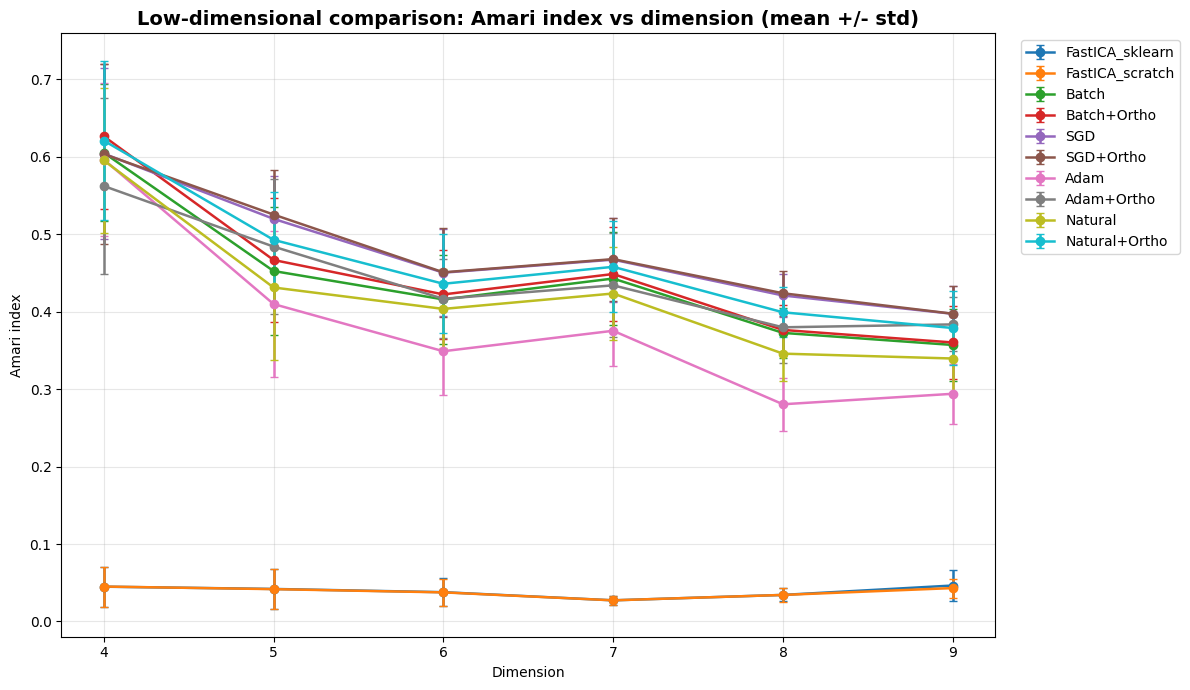

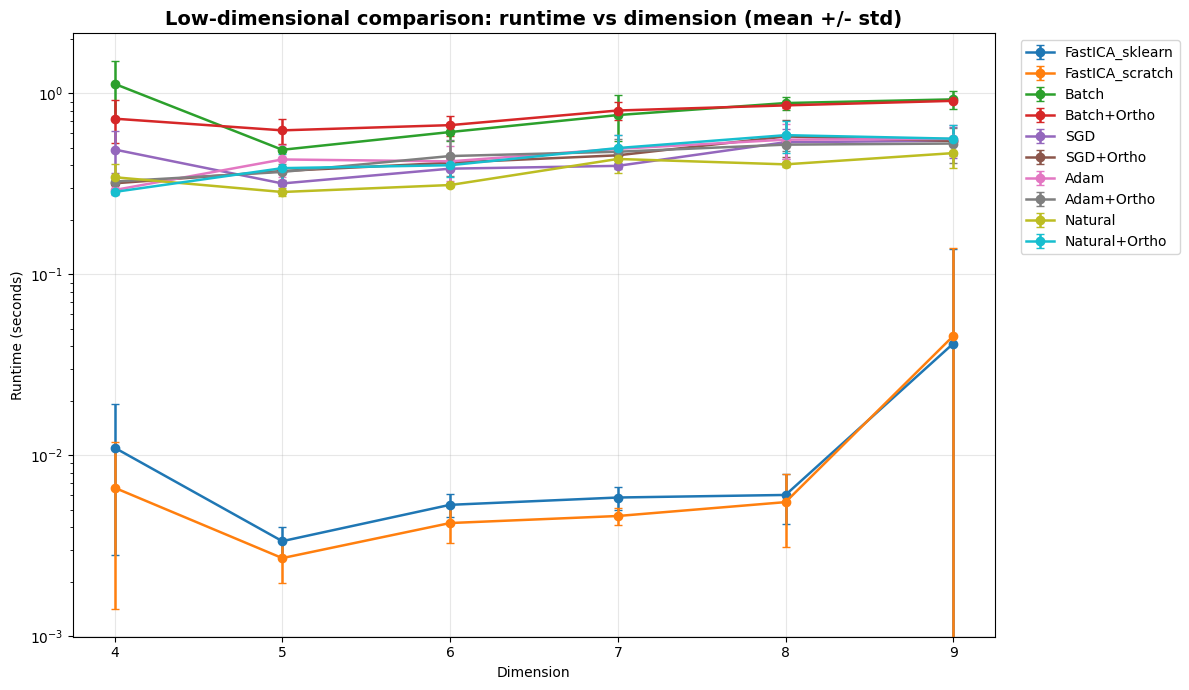

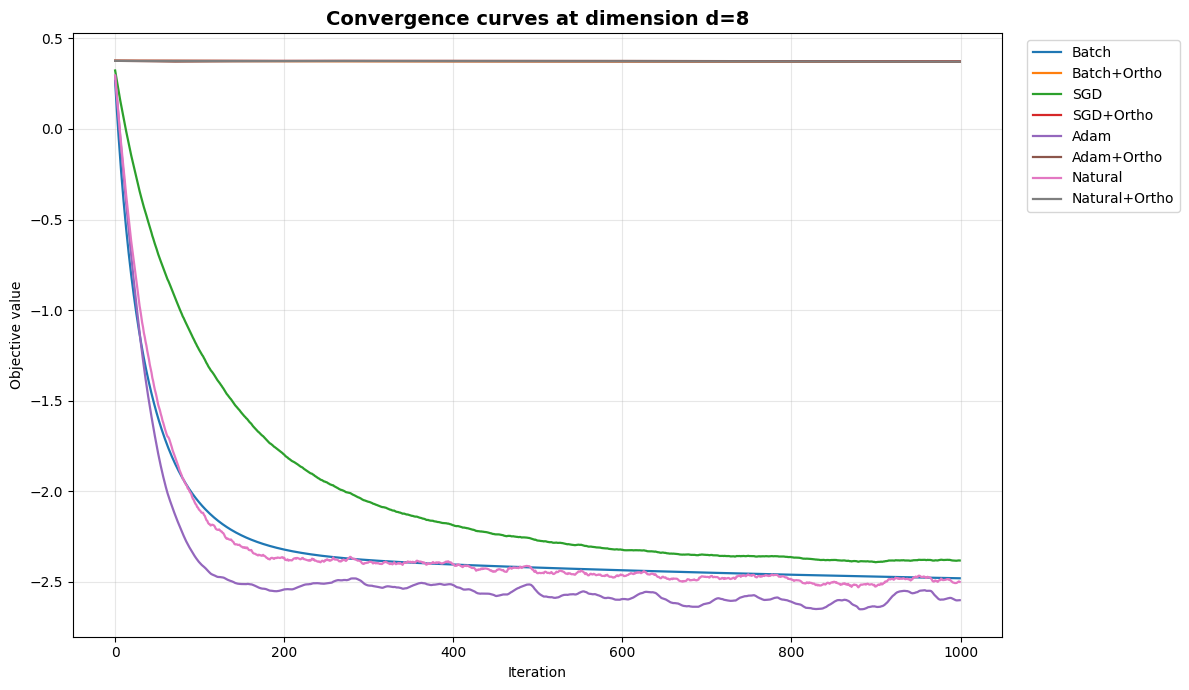

In [ ]:
low_dims = list(range(4, 10))
low_df, low_rep = run_experiment(dimensions=low_dims, n_runs=10, keep_representative=True)

display(low_df.head(12))

plot_metric_with_errorbars(
    low_df,
    metric_mean="Mean_Amari",
    metric_std="Std_Amari",
    title="Low-dimensional comparison: Amari index vs dimension (mean +/- std)",
    ylabel="Amari index",
)

plot_metric_with_errorbars(
    low_df,
    metric_mean="Mean_Time",
    metric_std="Std_Time",
    title="Low-dimensional comparison: runtime vs dimension (mean +/- std)",
    ylabel="Runtime (seconds)",
    logy=True,
)

plot_convergence(low_rep, dimension=8)


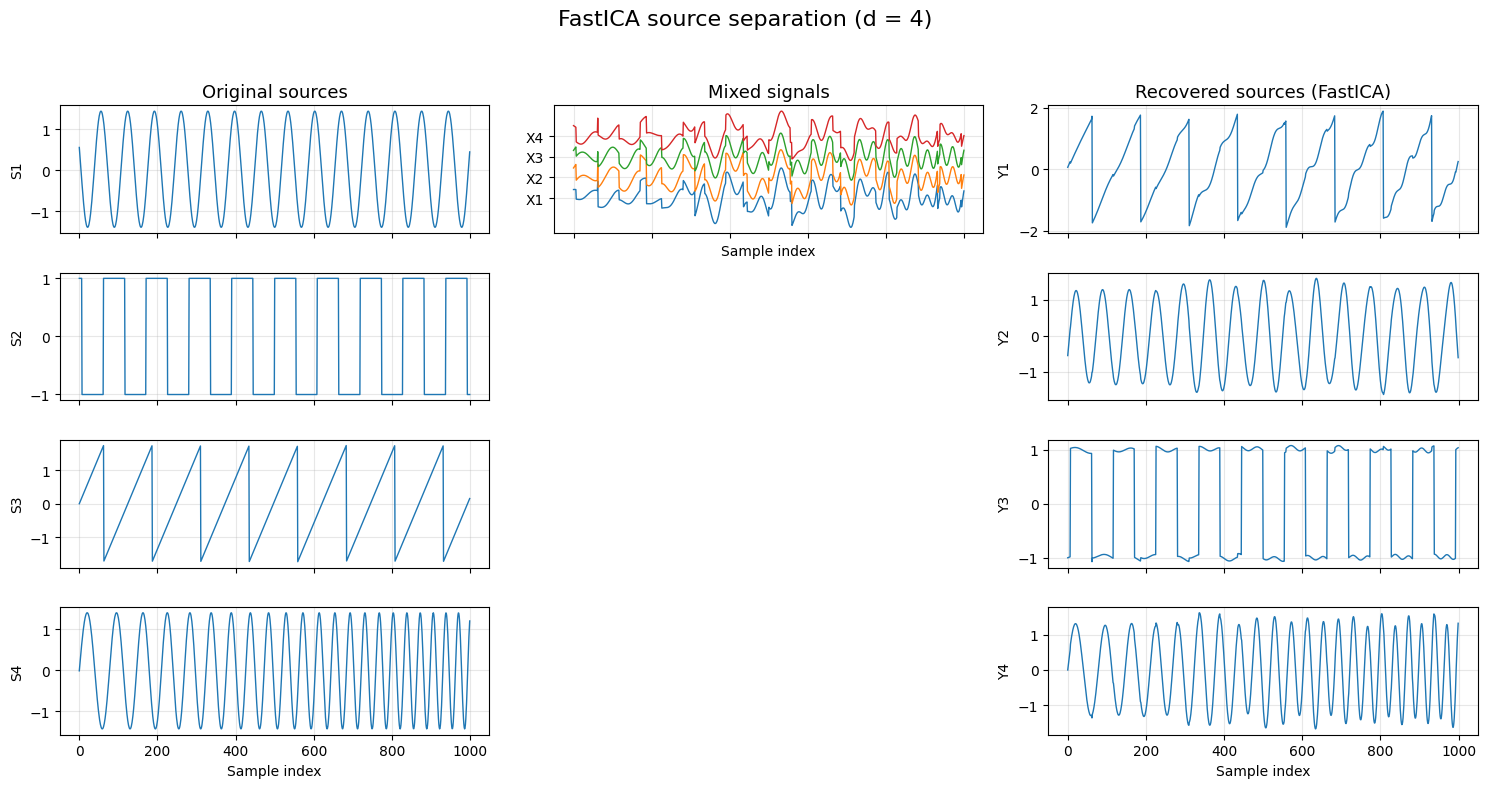

In [ ]:
# =========================
# FastICA signal separation demo (dim = 4)
# Original sources, stacked mixed signals, and recovered sources
# =========================
dim = 4
seed = 42

# Generate synthetic data
S_true, A_true, X = generate_mixture(n_sources=dim, n_samples=N_SAMPLES, seed=seed)

# Preprocess and run FastICA
X_white, whitening, mean_vec = preprocess(X)
result_fastica = fastica_baseline(X_white, random_state=seed)

# Align separated sources with true sources for visualization only
Y_est = align_sources(result_fastica.Y, S_true)

# Time axis
t = np.arange(S_true.shape[1])

# Plot
fig, axes = plt.subplots(dim, 3, figsize=(15, 8), sharex=True)
fig.suptitle("FastICA source separation (d = 4)", fontsize=16, y=0.98)

col_titles = ["Original sources", "Mixed signals", "Recovered sources (FastICA)"]
for j in range(3):
    axes[0, j].set_title(col_titles[j], fontsize=13)

# Original sources
for i in range(dim):
    axes[i, 0].plot(t, S_true[i], linewidth=1.0)
    axes[i, 0].set_ylabel(f"S{i+1}")
    axes[i, 0].grid(alpha=0.3)

# Middle column: stack 4 mixed signals with vertical offsets,
# but only draw them once in the first middle panel
offset = 5.0
ax_mix = axes[0, 1]
for i in range(dim):
    ax_mix.plot(t, X[i] + i * offset, linewidth=1.0, label=f"X{i+1}")
ax_mix.set_yticks([i * offset for i in range(dim)])
ax_mix.set_yticklabels([f"X{i+1}" for i in range(dim)])
ax_mix.grid(alpha=0.3)

# Hide the other 3 middle panels so the mixed panel appears as one box in the column
for i in range(1, dim):
    axes[i, 1].axis("off")

# Recovered sources
for i in range(dim):
    axes[i, 2].plot(t, Y_est[i], linewidth=1.0)
    axes[i, 2].set_ylabel(f"Y{i+1}")
    axes[i, 2].grid(alpha=0.3)

# X labels
axes[-1, 0].set_xlabel("Sample index")
ax_mix.set_xlabel("Sample index")
axes[-1, 2].set_xlabel("Sample index")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Discussion of low-dimensional results

### 1. Amari index

From the Amari index plot, **FastICA_sklearn** and **FastICA_scratch** clearly outperform all other methods across all tested dimensions \(d=4,\dots,9\). Their errors remain very small and stable, which shows that FastICA recovers the true independent sources much more accurately in the low-dimensional regime.

Among the gradient-based methods, **Adam** performs best overall, with the lowest Amari index in most cases. **Natural Gradient** is usually the second-best gradient-based method, while **Batch** and **SGD** are generally weaker. Although most gradient-based methods improve slightly as the dimension increases from 4 to 9, the gap with FastICA remains very large.

### 2. Runtime

In terms of runtime, **both FastICA versions are the fastest methods by a large margin**. They are substantially faster than all Infomax-based iterative methods. Therefore, in low dimensions, FastICA is not only the most accurate method, but also the most computationally efficient one.

Among the gradient-based methods, **Natural Gradient** and **Adam** are usually relatively faster, while **Batch+Ortho** is often the slowest. This is expected, since Batch uses the full dataset at every iteration and orthogonalization adds an extra matrix projection step.

### 3. Convergence

The convergence curves at \(d=8\) show clear differences in optimization behavior. **Adam** reaches the lowest objective value among the gradient-based methods, indicating that it converges to a better solution. **Batch** and **Natural Gradient** follow, while **SGD** converges more slowly and stabilizes at a higher objective value, which is consistent with its weaker Amari performance.

Therefore, from the convergence perspective, **Adam is the most effective and stable gradient-based optimizer**, whereas **SGD is one of the weakest gradient-based methods** in this setting.

## Conclusion for the low-dimensional regime

Overall, in the low-dimensional setting:

- **Best overall method:** **FastICA** (both sklearn and scratch), since it achieves the best Amari index and the shortest runtime.
- **Best gradient-based method:** **Adam**, because it gives the best trade-off between separation quality and convergence behavior.
- **Weakest methods:** **SGD** is generally one of the weakest gradient-based methods; **Batch+Ortho** is also not competitive because it is slower without improving accuracy.

Regarding orthogonalization, the `+Ortho` variants **do not provide a clear benefit in the low-dimensional regime**, and in many cases they even worsen the results. Both the Amari curves and the convergence behavior suggest that the orthogonal constraint is too restrictive here and may interfere with optimization rather than help it.


<a id="Scalability-analysis-(10-to-100)"></a>

## Scalability benchmark (d = 10 to 100)

**Task.** Evaluate the same algorithms on the required high-dimensional sweep:
$$d \in \{10,20,30,40,50,60,70,80,90,100\}.$$

The purpose is to study whether the ranking observed in low dimensions remains stable when the problem size increases, and whether stochastic or natural-gradient methods become more attractive as $d$ grows.


Running dimension d = 10
Running dimension d = 20
Running dimension d = 30
Running dimension d = 40
Running dimension d = 50
Running dimension d = 60
Running dimension d = 70
Running dimension d = 80
Running dimension d = 90
Running dimension d = 100


,Dimension,Algorithm,Mean_Amari,Std_Amari,Mean_Time,Std_Time,Mean_Iter,Std_Iter
0,10,FastICA_sklearn,0.037896,0.006630,0.343323,0.404755,407.6,483.705117
1,10,FastICA_scratch,0.035919,0.004644,0.143950,0.162554,210.4,236.518583
2,10,Batch,0.312297,0.038363,1.038595,0.118339,1000.0,0.000000
3,10,Batch+Ortho,0.316228,0.036376,0.985665,0.009395,1000.0,0.000000
4,10,SGD,0.376038,0.021693,0.501656,0.008949,1000.0,0.000000
5,10,SGD+Ortho,0.381783,0.022168,0.757044,0.139723,1000.0,0.000000
6,10,Adam,0.231803,0.021013,0.515002,0.013617,1000.0,0.000000
7,10,Adam+Ortho,0.369312,0.038835,0.602328,0.010849,1000.0,0.000000
8,10,Natural,0.287329,0.036670,0.462033,0.013010,1000.0,0.000000
9,10,Natural+Ortho,0.350268,0.021056,0.645397,0.118641,1000.0,0.000000


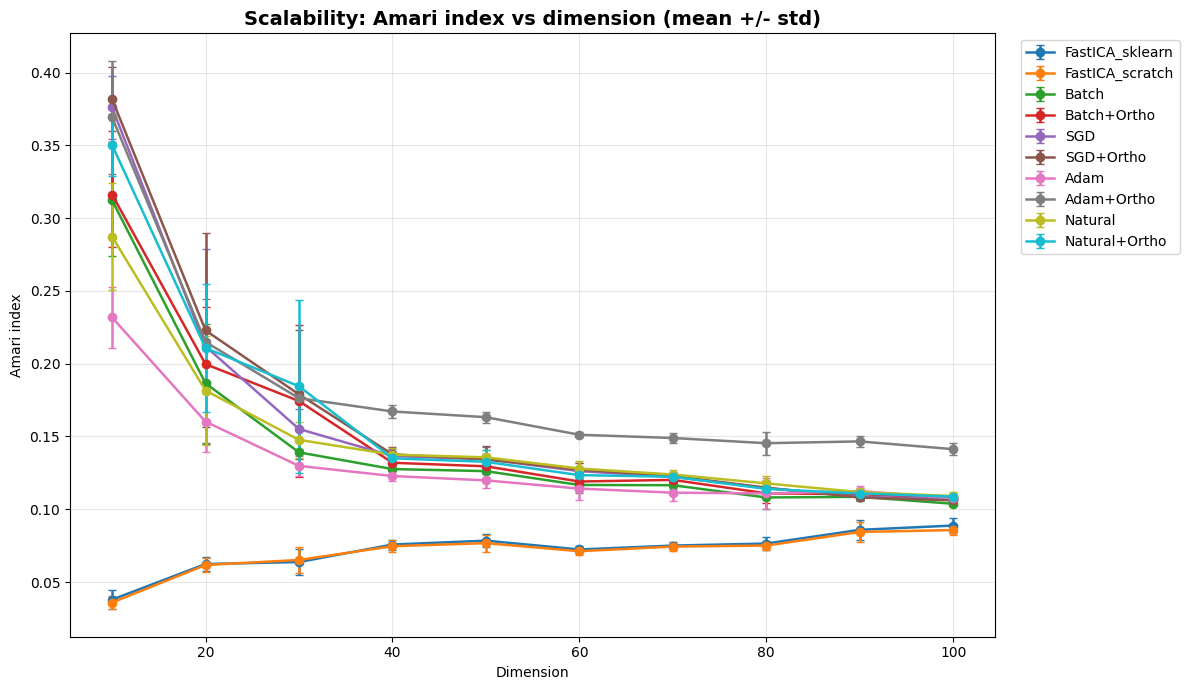

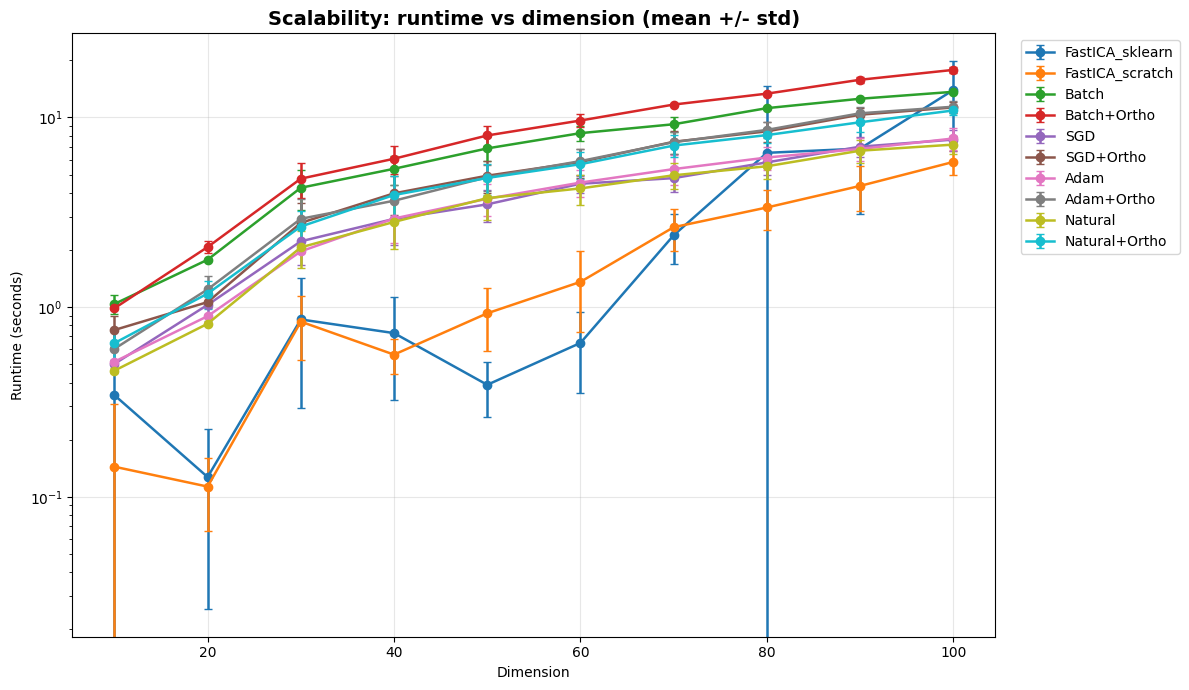

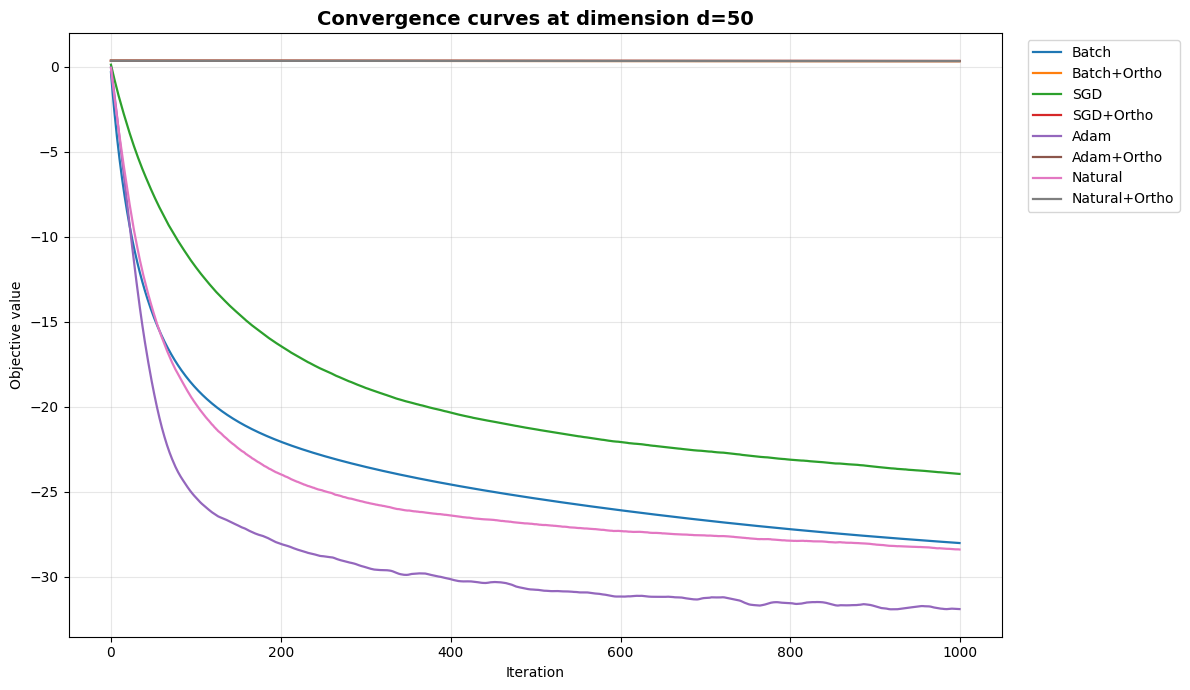

In [ ]:
high_dims = list(range(10, 101, 10))
high_df, high_rep = run_experiment(dimensions=high_dims, n_runs=5, keep_representative=True)

display(high_df.head(12))

plot_metric_with_errorbars(
    high_df,
    metric_mean="Mean_Amari",
    metric_std="Std_Amari",
    title="Scalability: Amari index vs dimension (mean +/- std)",
    ylabel="Amari index",
)

plot_metric_with_errorbars(
    high_df,
    metric_mean="Mean_Time",
    metric_std="Std_Time",
    title="Scalability: runtime vs dimension (mean +/- std)",
    ylabel="Runtime (seconds)",
    logy=True,
)

plot_convergence(high_rep, dimension=50)


### Discussion of scalability results

### 1. Amari index

From the scalability plot, **FastICA_sklearn** and **FastICA_scratch** still achieve the lowest Amari indices across all tested dimensions \(d=10,\dots,100\). Their error remains clearly below that of the gradient-based methods, which shows that FastICA continues to provide the most accurate source recovery in the high-dimensional regime.

Among the gradient-based methods, **Adam** performs best overall, with the lowest Amari index in most dimensions. **Natural Gradient** and **Batch** follow closely, while **Adam+Ortho** is clearly worse than the other variants and remains noticeably above the rest. In general, all gradient-based methods improve as the dimension increases, since their Amari indices decrease substantially from \(d=10\) to \(d=100\). However, even in high dimensions, they do not match the separation quality of FastICA.

### 2. Runtime

In terms of runtime, **FastICA remains faster than the gradient-based methods**, especially in the lower part of the high-dimensional range. However, as the dimension increases, its runtime also grows and becomes less negligible. Still, it remains competitive given its much stronger separation accuracy.

Among the gradient-based methods, **Adam**, **Natural Gradient**, and **SGD** are generally faster than the full-batch methods, while **Batch+Ortho** is consistently the slowest. This is expected, since full-batch updates are more expensive and orthogonalization introduces an additional matrix operation at every iteration. Overall, the runtime gap between methods becomes more visible as the dimension grows.

### 3. Convergence

The convergence curves at \(d=50\) again show clear differences in optimization behavior. **Adam** reaches the lowest objective value among the gradient-based methods, confirming that it converges to the best solution in this setting. **Natural Gradient** is the second-best method, while **Batch** converges more slowly and stabilizes at a higher objective level. **SGD** remains the weakest in terms of optimization efficiency.

The orthogonalized variants of Adam and Natural Gradient perform poorly in the convergence plot, remaining at much higher objective values. This is consistent with their weaker Amari performance and suggests that orthogonalization is too restrictive in this setting as well.

## Conclusion for the high-dimensional regime

Overall, in the high-dimensional setting:

- **Best overall method:** **FastICA** (both sklearn and scratch), since it still achieves the best Amari index and remains computationally competitive.
- **Best gradient-based method:** **Adam**, because it gives the best separation quality and the best convergence behavior among the optimization-based methods.
- **Weakest methods:** **SGD** remains one of the weakest gradient-based methods, and **Adam+Ortho** is particularly poor because its accuracy is clearly worse while its runtime is not improved.

Regarding orthogonalization, the `+Ortho` variants **do not provide a clear benefit in the high-dimensional regime either**. In several cases they even degrade performance, especially for Adam. As in the low-dimensional experiments, the orthogonal constraint seems to interfere with optimization more than it helps.


## Sensitivity analyses

### Learning-rate sensitivity

In [ ]:
# =========================
# Experiment: learning rate sensitivity
# Methods: Batch, SGD, Adam, Natural Gradient
# Dimension: d = 8
# Runs: 5
# =========================
d_exp = 8
n_runs_exp = 5

batch_lrs = [5e-4, 1e-3, 2e-3, 5e-3, 1e-2, 2e-2]
sgd_lrs = [5e-4, 1e-3, 2e-3, 5e-3, 1e-2, 2e-2]
adam_lrs = [5e-4, 1e-3, 2e-3, 5e-3, 1e-2, 2e-2]
natural_lrs = [5e-4, 1e-3, 2e-3, 5e-3, 1e-2, 2e-2]

records_lr = []

# Batch
for lr in batch_lrs:
    scores = []
    for run in range(n_runs_exp):
        seed = SEED + run
        S, A, X = generate_mixture(n_sources=d_exp, n_samples=N_SAMPLES, seed=seed)
        X_white, whitening, _ = preprocess(X)
        result = batch_infomax(X_white, lr=lr, random_state=seed, orthogonalize=True)
        W_orig = result.W @ whitening
        score = amari_index(W_orig, A)
        scores.append(score)
    records_lr.append({"Method": "Batch", "Learning rate": lr, "Mean_Amari": np.mean(scores), "Std_Amari": np.std(scores)})

# SGD
for lr in sgd_lrs:
    scores = []
    for run in range(n_runs_exp):
        seed = SEED + run
        S, A, X = generate_mixture(n_sources=d_exp, n_samples=N_SAMPLES, seed=seed)
        X_white, whitening, _ = preprocess(X)
        result = sgd_infomax(X_white, lr=lr, random_state=seed, orthogonalize=True)
        W_orig = result.W @ whitening
        score = amari_index(W_orig, A)
        scores.append(score)
    records_lr.append({"Method": "SGD", "Learning rate": lr, "Mean_Amari": np.mean(scores), "Std_Amari": np.std(scores)})

# Adam
for lr in adam_lrs:
    scores = []
    for run in range(n_runs_exp):
        seed = SEED + run
        S, A, X = generate_mixture(n_sources=d_exp, n_samples=N_SAMPLES, seed=seed)
        X_white, whitening, _ = preprocess(X)
        result = adam_infomax(X_white, lr=lr, random_state=seed, orthogonalize=True)
        W_orig = result.W @ whitening
        score = amari_index(W_orig, A)
        scores.append(score)
    records_lr.append({"Method": "Adam", "Learning rate": lr, "Mean_Amari": np.mean(scores), "Std_Amari": np.std(scores)})

# Natural Gradient
for lr in natural_lrs:
    scores = []
    for run in range(n_runs_exp):
        seed = SEED + run
        S, A, X = generate_mixture(n_sources=d_exp, n_samples=N_SAMPLES, seed=seed)
        X_white, whitening, _ = preprocess(X)
        result = natural_gradient_ica(X_white, lr=lr, random_state=seed, orthogonalize=True)
        W_orig = result.W @ whitening
        score = amari_index(W_orig, A)
        scores.append(score)
    records_lr.append({"Method": "Natural Gradient", "Learning rate": lr, "Mean_Amari": np.mean(scores), "Std_Amari": np.std(scores)})

df_lr = pd.DataFrame(records_lr)
df_lr

,Method,Learning rate,Mean_Amari,Std_Amari
0,Batch,0.0005,0.397850,0.035156
1,Batch,0.0010,0.397866,0.035154
2,Batch,0.0020,0.398137,0.034735
3,Batch,0.0050,0.402838,0.035208
4,Batch,0.0100,0.400868,0.039077
5,Batch,0.0200,0.395483,0.040593
6,SGD,0.0005,0.397850,0.035154
7,SGD,0.0010,0.397868,0.035150
8,SGD,0.0020,0.398311,0.034686
9,SGD,0.0050,0.401908,0.035629


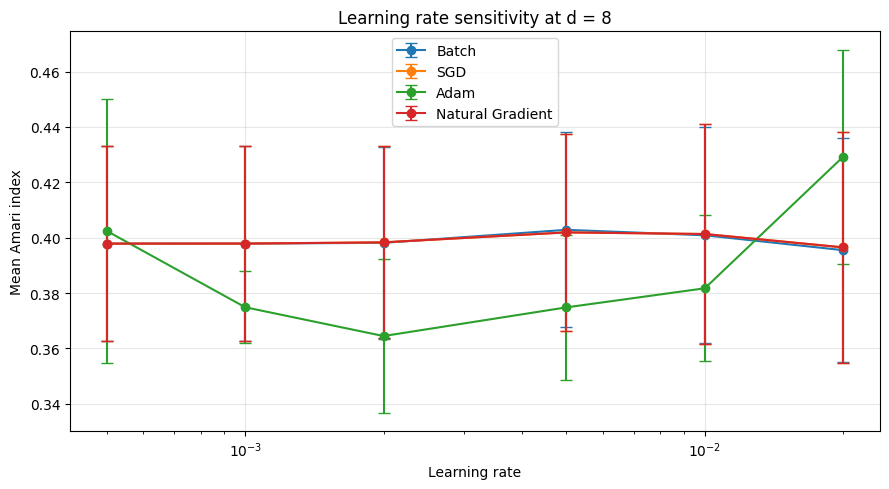

In [ ]:
# =========================
# Plot: learning rate sensitivity
# =========================
plt.figure(figsize=(9, 5))

for method in ["Batch", "SGD", "Adam", "Natural Gradient"]:
    sub = df_lr[df_lr["Method"] == method].sort_values("Learning rate")
    plt.errorbar(
        sub["Learning rate"],
        sub["Mean_Amari"],
        yerr=sub["Std_Amari"],
        marker="o",
        capsize=4,
        label=method
    )

plt.xscale("log")
plt.xlabel("Learning rate")
plt.ylabel("Mean Amari index")
plt.title("Learning rate sensitivity at d = 8")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

The learning-rate sensitivity plot shows that Adam is the only method that is clearly sensitive to the learning rate. Its performance is best in the range 0.001 to 0.01, while using a larger value leads to a noticeable deterioration in the Amari index. In contrast, Batch, SGD, and Natural Gradient are much less sensitive, since their curves remain almost flat over the tested range.

This result is consistent with the learning rates chosen earlier:
LR_BATCH = 0.03, LR_SGD = 0.01, LR_ADAM = 0.008, and LR_NATURAL = 0.02.
In particular, the selected value for Adam lies inside its stable and effective range, while the values chosen for the other methods are reasonable because those methods are not strongly affected by the learning rate in this experiment. Therefore, this sensitivity analysis supports the overall validity of the original learning-rate settings.

### Initialization sensitivity

In [ ]:
# =========================
# Methods: FastICA_scratch, Batch, SGD, Adam, Natural Gradient
# Dimension: d = 8
# Runs: 5
# =========================
d_exp = 8
n_runs_exp = 5

methods = ["FastICA_scratch", "Batch", "SGD", "Adam", "Natural Gradient"]
init_modes = ["identity_noise", "random_gaussian", "random_orthogonal"]

records_init = []

for method in methods:
    for init_mode in init_modes:
        scores = []
        for run in range(n_runs_exp):
            seed = SEED + run
            rng = np.random.default_rng(seed)
            S, A, X = generate_mixture(n_sources=d_exp, n_samples=N_SAMPLES, seed=seed)
            X_white, whitening, _ = preprocess(X)

            if init_mode == "identity_noise":
                W = np.eye(d_exp) + 0.01 * rng.standard_normal((d_exp, d_exp))
            elif init_mode == "random_gaussian":
                W = rng.standard_normal((d_exp, d_exp))
            elif init_mode == "random_orthogonal":
                Q, R = np.linalg.qr(rng.standard_normal((d_exp, d_exp)))
                signs = np.sign(np.diag(R))
                signs[signs == 0] = 1.0
                W = Q @ np.diag(signs)
            else:
                raise ValueError("Unknown initialization mode.")

            if method == "FastICA_scratch":
                W_fast = symmetric_orthogonalization(W.copy())
                for it in range(MAX_ITER):
                    WX = W_fast @ X_white
                    g = np.tanh(WX)
                    g_prime = 1 - g**2
                    W_new = (g @ X_white.T) / X_white.shape[1] - np.diag(g_prime.mean(axis=1)) @ W_fast
                    W_new = symmetric_orthogonalization(W_new)
                    diff = np.max(np.abs(np.abs(np.diag(W_new @ W_fast.T)) - 1))
                    W_fast = W_new
                    if diff < 1e-6: break
                W_est = W_fast

            elif method == "Batch":
                W_batch = W.copy()
                costs = []
                for it in range(MAX_ITER):
                    grad = infomax_gradient(W_batch, X_white)
                    grad = clip_grad(grad)
                    W_batch = W_batch - LR_BATCH * grad
                    W_batch = symmetric_orthogonalization(W_batch)
                    cost = infomax_objective(W_batch, X_white)
                    costs.append(cost)
                    if not np.isfinite(cost): break
                    if has_converged(costs): break
                W_est = W_batch

            elif method == "SGD":
                W_sgd = W.copy()
                costs = []
                for it in range(MAX_ITER):
                    idx = np.random.choice(X_white.shape[1], size=min(BATCH_SIZE, X_white.shape[1]), replace=False)
                    Xb = X_white[:, idx]
                    grad = infomax_gradient(W_sgd, Xb)
                    grad = clip_grad(grad)
                    W_sgd = W_sgd - LR_SGD * grad
                    W_sgd = symmetric_orthogonalization(W_sgd)
                    cost = infomax_objective(W_sgd, X_white)
                    costs.append(cost)
                    if not np.isfinite(cost): break
                    if has_converged(costs): break
                W_est = W_sgd

            elif method == "Adam":
                W_adam = W.copy()
                m = np.zeros_like(W_adam)
                v = np.zeros_like(W_adam)
                costs = []
                for it in range(1, MAX_ITER + 1):
                    idx = np.random.choice(X_white.shape[1], size=min(BATCH_SIZE, X_white.shape[1]), replace=False)
                    Xb = X_white[:, idx]
                    grad = infomax_gradient(W_adam, Xb)
                    grad = clip_grad(grad)
                    m = 0.9 * m + 0.1 * grad
                    v = 0.999 * v + 0.001 * (grad ** 2)
                    m_hat = m / (1 - 0.9 ** it)
                    v_hat = v / (1 - 0.999 ** it)
                    W_adam = W_adam - LR_ADAM * m_hat / (np.sqrt(v_hat) + 1e-8)
                    W_adam = symmetric_orthogonalization(W_adam)
                    cost = infomax_objective(W_adam, X_white)
                    costs.append(cost)
                    if not np.isfinite(cost): break
                    if has_converged(costs): break
                W_est = W_adam

            elif method == "Natural Gradient":
                W_nat = W.copy()
                costs = []
                for it in range(MAX_ITER):
                    idx = np.random.choice(X_white.shape[1], size=min(BATCH_SIZE, X_white.shape[1]), replace=False)
                    Xb = X_white[:, idx]
                    grad_nat = natural_gradient_direction(W_nat, Xb)
                    grad_nat = clip_grad(grad_nat)
                    W_nat = W_nat - LR_NATURAL * grad_nat
                    W_nat = symmetric_orthogonalization(W_nat)
                    cost = infomax_objective(W_nat, X_white)
                    costs.append(cost)
                    if not np.isfinite(cost): break
                    if has_converged(costs): break
                W_est = W_nat

            else:
                raise ValueError("Unknown method.")

            W_orig = W_est @ whitening
            score = amari_index(W_orig, A)
            scores.append(score)

        records_init.append({"Method": method, "Initialization": init_mode, "Mean_Amari": np.mean(scores), "Std_Amari": np.std(scores)})

df_init_all = pd.DataFrame(records_init)
df_init_all

,Method,Initialization,Mean_Amari,Std_Amari
0,FastICA_scratch,identity_noise,0.028245,0.001897
1,FastICA_scratch,random_gaussian,0.028232,0.001879
2,FastICA_scratch,random_orthogonal,0.028239,0.001889
3,Batch,identity_noise,0.391792,0.036808
4,Batch,random_gaussian,0.380438,0.019248
5,Batch,random_orthogonal,0.410492,0.019748
6,SGD,identity_noise,0.401649,0.038818
7,SGD,random_gaussian,0.389108,0.028743
8,SGD,random_orthogonal,0.421804,0.019037
9,Adam,identity_noise,0.397746,0.042066


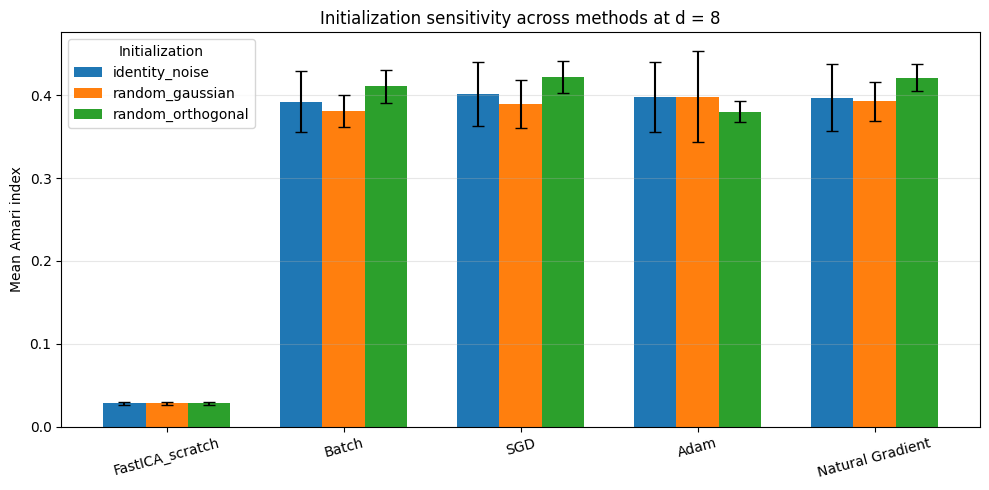

In [ ]:
# =========================
# Plot: initialization sensitivity across five methods
# =========================
methods_order = ["FastICA_scratch", "Batch", "SGD", "Adam", "Natural Gradient"]
init_order = ["identity_noise", "random_gaussian", "random_orthogonal"]

pivot_mean = df_init_all.pivot(index="Method", columns="Initialization", values="Mean_Amari").loc[methods_order, init_order]
pivot_std = df_init_all.pivot(index="Method", columns="Initialization", values="Std_Amari").loc[methods_order, init_order]

x = np.arange(len(methods_order))
width = 0.24

plt.figure(figsize=(10, 5))

for i, init_mode in enumerate(init_order):
    plt.bar(
        x + (i - 1) * width,
        pivot_mean[init_mode].values,
        width=width,
        yerr=pivot_std[init_mode].values,
        capsize=4,
        label=init_mode
    )

plt.xticks(x, methods_order, rotation=15)
plt.ylabel("Mean Amari index")
plt.title("Initialization sensitivity across methods at d = 8")
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Initialization")
plt.tight_layout()
plt.show()

The initialization sensitivity plot shows that all five methods are relatively insensitive to the choice of initialization at d=8. For each method, the mean Amari indices under the three initialization strategies are close to each other, and in most cases the error bars overlap. This indicates that changing the initialization from identity plus small noise to random Gaussian or random orthogonal does not substantially affect the final separation quality.

<a id="Part-1-summary"></a>

## Part 1 summary

Part 1 shows a clear and consistent pattern across both low- and high-dimensional synthetic experiments. FastICA is the best overall method, since it achieves the lowest Amari index in all tested settings while remaining the fastest or among the fastest methods. Among the gradient-based solvers, Adam is the strongest and most reliable choice, with the best separation quality and convergence behavior, while Natural Gradient is usually the second-best alternative. By contrast, SGD and the full-batch methods are generally less competitive, and the +Ortho variants do not provide a consistent advantage; in many cases, orthogonalization even degrades performance. The additional sensitivity analyses also show that the main conclusions are robust: learning rate matters mainly for Adam, while initialization has only a limited effect overall.

**Therefore, the main takeaway from Part 1 is that FastICA should be preferred as the reference method for synthetic ICA benchmarks, while Adam and Natural gradientis the best gradient-based alternative when an optimization-based solver is needed.**


<a id="Part-2-—-ICA-with-missing-data"></a>

## Part 2 — ICA with missing data

<a id="Task-and-protocol"></a>

### Problem setup and workflow

**Task.** Extend ICA to settings where the observed mixture contains missing entries. We study three missingness structures:

- **random missing:** entries are independently removed;
- **block missing:** contiguous time intervals are removed;
- **dropout missing:** one or more channels disappear on time blocks.

The workflow is:
1. create synthetic mixtures with known ground truth;
2. inject one missingness pattern at a fixed rate;
3. compare three solver families (**FastICA**, **Adam**, **Natural gradient**) under three handling strategies (**baseline**, **structured**, **masked**);
4. transfer the best-performing methods to a real EEG denoising task.

The central question is whether the best ICA strategy depends on the **geometry of missingness**.


<a id="Missing-data-utilities"></a>

### Missing-data preprocessing utilities

This section defines the synthetic generator, the missingness masks, and preprocessing rules.

Let $M \in \{0,1\}^{d \times n}$ be the observation mask, where $M_{ij}=1$ means "observed" and $M_{ij}=0$ means "missing". The observed matrix is
$$X_{\text{miss}} = M \odot X + (1-M) \odot \text{NaN}.$$


### Preprocessing Strategies

To handle missing values, three preprocessing strategies are implemented.

**Baseline strategy**

Missing values are replaced with the empirical mean of the corresponding variable. The completed matrix is then processed using the standard ICA preprocessing pipeline (centering and whitening).

**Structured strategy**

The imputation method depends on the missingness pattern. For random missingness, mean imputation is used. For block gaps or channel dropouts, missing segments are reconstructed using linear interpolation.

**Masked strategy**

Instead of explicitly imputing missing values, the mask is incorporated directly into preprocessing. Means are computed using observed entries only, and the covariance matrix is estimated using pairwise observed samples. Whitening is then performed using this covariance estimate.

### ICA Solvers

After preprocessing, the whitened data are passed to one of three ICA algorithms:

- **FastICA**
- **Adam-based Infomax**
- **Natural Gradient ICA**

For the masked strategy, the solvers are initialized using a standard ICA estimate and then refined using masked gradient updates that ignore missing entries.

### Experimental Setup

Combining the three preprocessing strategies with the three ICA solvers results in nine different methods:

- FastICA + baseline
- FastICA + structured
- FastICA + masked
- Adam + baseline
- Adam + structured
- Adam + masked
- Natural Gradient + baseline
- Natural Gradient + structured
- Natural Gradient + masked

Each configuration is evaluated on synthetic datasets with different missingness patterns and dimensions. Performance is measured using the **Amari index**, along with runtime and the number of iterations.

In [3]:

# =========================
# Part 2 configuration
# =========================
PART2_N_SAMPLES = 2000
PART2_DIMENSIONS = [4,6,8,10,20,30,40,50,60,70]
PART2_PATTERNS = ["random", "block", "dropout"]
PART2_MISSING_RATE = 0.1
PART2_RUNS = 5

PART2_MAX_ITER = 500
PART2_MASKED_STEPS = 150
PART2_EPS = 1e-6

# EEG Experiment Specific Parameters
EEG_EXPERIMENT_DIM = 59
EEG_EXPERIMENT_MISSING_RATE = 0.1



### Synthetic benchmark under missing data

For each dimension `d = 4,6,8,10,20,30,40,50,60,70`, we:

1. generate a synthetic ICA mixture with known mixing matrix `A`;
2. impose one missingness pattern;
3. run the 3 solvers × 3 variants;
4. compute the **Amari index**;
5. aggregate results as **mean ± std** over repeated runs.


In [ ]:
# ============================================================
# Part 2 utilities
# Synthetic data, missing masks, preprocessing strategies
# ============================================================

def generate_part2_mixture(n_sources:int,seed:int)->Tuple[np.ndarray,np.ndarray,np.ndarray]:
    """Generate synthetic ICA mixture."""
    return generate_mixture(n_sources=n_sources,n_samples=PART2_N_SAMPLES,seed=seed)


def make_missing_mask(shape:Tuple[int,int],pattern:str,missing_rate:float,seed:int)->np.ndarray:
    """Create missingness mask: random / block / dropout."""
    rng=np.random.default_rng(seed); d,n=shape; M=np.ones((d,n))
    if missing_rate<=0: return M

    if pattern=="random": return (rng.random((d,n))>missing_rate).astype(float)

    target=int(round(missing_rate*d*n)); block=max(10,n//12 if pattern=="block" else n//10); miss=0
    while miss<target:
        start=int(rng.integers(0,max(1,n-block))); end=min(n,start+block)
        if pattern=="block":
            before=M[:,start:end].sum(); M[:,start:end]=0; miss+=int(before-M[:,start:end].sum())
        else:
            ch=rng.choice(d,size=int(rng.integers(1,min(3,d)+1)),replace=False)
            before=M[ch,start:end].sum(); M[ch,start:end]=0; miss+=int(before-M[ch,start:end].sum())
    return M


def apply_mask(X:np.ndarray,M:np.ndarray)->np.ndarray:
    """Replace missing entries by NaN."""
    X=X.copy(); X[M==0]=np.nan; return X


# ============================================================
# Masked preprocessing utilities
# ============================================================

def masked_center(X:np.ndarray,M:np.ndarray)->Tuple[np.ndarray,np.ndarray]:
    """Center rows using observed entries only."""
    obs=np.maximum(M.sum(axis=1,keepdims=True),1.0)
    mean=np.nansum(np.where(M==1,X,0),axis=1,keepdims=True)/obs
    return np.where(M==1,X-mean,0),mean


def pairwise_covariance(X:np.ndarray,M:np.ndarray,eps:float=PART2_EPS)->np.ndarray:
    """Covariance using pairwise observed samples."""
    d=X.shape[0]; C=np.zeros((d,d))
    for i in range(d):
        for j in range(i,d):
            v=M[i]*M[j]; c=v.sum()
            val=0 if c<=1 else np.sum(X[i]*X[j]*v)/c
            C[i,j]=C[j,i]=val
    return 0.5*(C+C.T)+eps*np.eye(d)


def whiten_from_cov(X:np.ndarray,C:np.ndarray,eps:float=PART2_EPS)->Tuple[np.ndarray,np.ndarray]:
    """Whiten using eigen-decomposition."""
    eigval,eigvec=np.linalg.eigh(C); idx=np.argsort(eigval)[::-1]
    eigval,eigvec=np.maximum(eigval[idx],eps),eigvec[:,idx]
    W=np.diag(1/np.sqrt(eigval))@eigvec.T
    Xw=W@X; Xw=Xw/(np.std(Xw,axis=1,keepdims=True)+eps)
    return Xw,W


# ============================================================
# Completion utilities (baseline / structured)
# ============================================================

def _linear_interpolate_row(row:np.ndarray)->np.ndarray:
    """Linear interpolation for missing segments."""
    row=row.astype(float).copy(); idx=np.arange(row.size); ok=~np.isnan(row)
    if ok.sum()==0: return np.zeros_like(row)
    if ok.sum()==1: row[~ok]=row[ok][0]; return row
    row[~ok]=np.interp(idx[~ok],idx[ok],row[ok]); return row


def complete_for_variant(X:np.ndarray,M:np.ndarray,pattern:str,variant:str)->np.ndarray:
    """Fill missing values depending on strategy."""
    if variant=="baseline":
        mu=np.nanmean(X,axis=1,keepdims=True); X=np.where(M==1,X,mu)
    elif variant=="structured":
        X=np.where(M==1,X,np.nanmean(X,axis=1,keepdims=True)) if pattern=="random" else np.vstack([_linear_interpolate_row(r) for r in X])
    else: raise ValueError("baseline / structured only")
    return np.asarray(X,float)


# ============================================================
# Unified preprocessing interface
# ============================================================

def preprocess_variant(X:np.ndarray,M:np.ndarray,pattern:str,variant:str):
    """Apply baseline / structured / masked preprocessing."""
    if variant in {"baseline","structured"}:
        X=complete_for_variant(X,M,pattern,variant); Xw,W,mu=preprocess(X); return Xw,W,mu,np.ones_like(X)
    if variant=="masked":
        Xc,mu=masked_center(X,M); C=pairwise_covariance(Xc,M); Xw,W=whiten_from_cov(Xc,C); return Xw,W,mu,M.copy()
    raise ValueError("variant must be baseline / structured / masked")


# ============================================================
# ICA objective and masked gradient
# ============================================================

def stable_logcosh(U:np.ndarray)->np.ndarray: return np.logaddexp(U,-U)-np.log(2.0)


def infomax_objective_stable(W:np.ndarray,X:np.ndarray)->float:
    Y=W@X; s,logdet=np.linalg.slogdet(W)
    return np.inf if s==0 else float(-logdet+np.mean(stable_logcosh(Y)))


def infomax_gradient_masked(W:np.ndarray,X:np.ndarray,M:np.ndarray)->np.ndarray:
    Y=W@X; g=np.tanh(Y); obs=max(np.mean(M),PART2_EPS)
    return -np.linalg.inv(W.T+PART2_EPS*np.eye(W.shape[0]))+(g@(X*M).T)/(X.shape[1]*obs)


# ============================================================
# Masked optimization refinement
# ============================================================

def masked_refinement(W_init,X,M,mode,seed,steps=PART2_MASKED_STEPS,lrA=LR_ADAM,lrN=LR_NATURAL,batch=BATCH_SIZE)->ICAResult:
    set_seed(seed); d,n=X.shape; W=W_init.copy(); costs=[]; m=np.zeros_like(W); v=np.zeros_like(W); start=time.time()
    for t in range(1,steps+1):
        idx=np.random.choice(n,size=min(batch,n),replace=False); Xb,Mb=X[:,idx],M[:,idx]
        if mode=="adam":
            g=clip_grad(infomax_gradient_masked(W,Xb,Mb)); m=.9*m+.1*g; v=.999*v+.001*g**2
            W-=lrA*(m/(1-.9**t))/(np.sqrt(v/(1-.999**t))+1e-8)
        else:
            Y=W@Xb; obs=max(np.mean(Mb),PART2_EPS); rel=(-np.eye(d)+(np.tanh(Y)@(Y*Mb).T)/(Xb.shape[1]*obs))@W
            W-=lrN*clip_grad(rel)
        c=infomax_objective_stable(W,X); costs.append(c)
        if not np.isfinite(c) or has_converged(costs,tol=TOLERANCE,patience=min(PATIENCE,15)): break
    return ICAResult(name=f"masked_{mode}",W=W,Y=W@X,costs=costs,n_iter=len(costs),elapsed=time.time()-start)


# ============================================================
# Solver dispatch
# ============================================================

def run_base_solver(solver:str,X:np.ndarray,seed:int)->ICAResult:
    if solver=="FastICA": return fastica_baseline(X,random_state=seed,max_iter=PART2_MAX_ITER)
    if solver=="Adam": return adam_infomax(X,random_state=seed,max_iter=PART2_MAX_ITER)
    if solver=="Natural": return natural_gradient_ica(X,random_state=seed,max_iter=PART2_MAX_ITER)
    raise ValueError("FastICA / Adam / Natural only")


def run_solver_variant(solver:str,variant:str,X:np.ndarray,M:np.ndarray,seed:int)->ICAResult:
    if variant in {"baseline","structured"}: return run_base_solver(solver,X,seed)
    if solver=="FastICA": init=fastica_baseline(X,random_state=seed,max_iter=PART2_MAX_ITER); return masked_refinement(init.W,X,M,"natural",seed)
    if solver=="Adam": init=adam_infomax(X,random_state=seed,max_iter=200); return masked_refinement(init.W,X,M,"adam",seed)
    if solver=="Natural": init=natural_gradient_ica(X,random_state=seed,max_iter=200); return masked_refinement(init.W,X,M,"natural",seed)
    raise ValueError("invalid solver")


# ============================================================
# Experiment evaluation
# ============================================================

PART2_SOLVERS=["FastICA","Adam","Natural"]
PART2_VARIANTS=["baseline","structured","masked"]

def method_label(solver:str,variant:str)->str: return f"{solver}_{variant}"


def evaluate_missing_case(d:int,pattern:str,variant:str,solver:str,seed:int)->Dict[str,float]:
    S,A,X=generate_part2_mixture(d,seed); M=make_missing_mask(X.shape,pattern,PART2_MISSING_RATE,seed+1000)
    Xmiss=apply_mask(X,M); Xw,W,mu,Mw=preprocess_variant(Xmiss,M,pattern,variant)
    res=run_solver_variant(solver,variant,Xw,Mw,seed)
    score=amari_index(res.W@W,A)
    return {"Amari":score,"Time":res.elapsed,"Iterations":res.n_iter}


def run_part2_synthetic(dimensions=PART2_DIMENSIONS,patterns=PART2_PATTERNS,solvers=PART2_SOLVERS,variants=PART2_VARIANTS,n_runs=PART2_RUNS)->pd.DataFrame:
    rows=[]
    for p in patterns:
        for d in dimensions:
            print(f"Pattern={p:>7s} | d={d}")
            for s in solvers:
                for v in variants:
                    A,T,I=[],[],[]
                    for r in range(n_runs):
                        seed=5000+100*d+10*r+len(p)+len(s)+len(v)
                        out=evaluate_missing_case(d,p,v,s,seed)
                        A.append(out["Amari"]); T.append(out["Time"]); I.append(out["Iterations"])
                    rows.append({"Pattern":p,"Dimension":d,"Solver":s,"Variant":v,"Method":method_label(s,v),
                                 "Mean_Amari":np.mean(A),"Std_Amari":np.std(A),
                                 "Mean_Time":np.mean(T),"Std_Time":np.std(T),
                                 "Mean_Iter":np.mean(I),"Std_Iter":np.std(I)})
    return pd.DataFrame(rows)

In [ ]:
# Full run
part2_synth_df = run_part2_synthetic()
display(part2_synth_df.head())


Pattern= random | d=4
Pattern= random | d=6
Pattern= random | d=8
Pattern= random | d=10
Pattern= random | d=20
Pattern= random | d=30
Pattern= random | d=40
Pattern= random | d=50
Pattern= random | d=60
Pattern= random | d=70
Pattern=  block | d=4
Pattern=  block | d=6
Pattern=  block | d=8
Pattern=  block | d=10
Pattern=  block | d=20
Pattern=  block | d=30
Pattern=  block | d=40
Pattern=  block | d=50
Pattern=  block | d=60
Pattern=  block | d=70
Pattern=dropout | d=4
Pattern=dropout | d=6
Pattern=dropout | d=8
Pattern=dropout | d=10
Pattern=dropout | d=20
Pattern=dropout | d=30
Pattern=dropout | d=40
Pattern=dropout | d=50
Pattern=dropout | d=60
Pattern=dropout | d=70


,Pattern,Dimension,Solver,Variant,Method,Mean_Amari,Std_Amari,Mean_Time,Std_Time,Mean_Iter,Std_Iter
0,random,4,FastICA,baseline,FastICA_baseline,0.382165,0.099958,0.007989,0.008147,6.8,1.939072
1,random,4,FastICA,structured,FastICA_structured,0.387994,0.114818,0.056226,0.086222,120.6,190.951931
2,random,4,FastICA,masked,FastICA_masked,0.462324,0.083007,0.133861,0.005801,150.0,0.000000
3,random,4,Adam,baseline,Adam_baseline,0.447925,0.077613,0.241998,0.012382,500.0,0.000000
4,random,4,Adam,structured,Adam_structured,0.469296,0.048098,0.356815,0.083202,500.0,0.000000



### Synthetic benchmark outputs

The next cells summarize Part 2 in the report-ready format:

- **best method for each pattern**
- **dimension sweep curves**


,Pattern,Method,Solver,Variant,Mean_Amari,Std_Amari,Mean_Time
0,block,FastICA_structured,FastICA,structured,0.101903,0.020933,0.784028
1,dropout,Natural_masked,Natural,masked,0.291559,0.061789,0.499205
2,random,Natural_masked,Natural,masked,0.276017,0.081631,0.528672


,Pattern,Dim_Regime,Method,Solver,Variant,Mean_Amari,Std_Amari,Mean_Time
0,block,high,FastICA_baseline,FastICA,baseline,0.080671,0.007539,0.645893
1,block,low,FastICA_structured,FastICA,structured,0.101987,0.026375,0.066002
2,dropout,high,Natural_masked,Natural,masked,0.241639,0.014871,0.860413
3,dropout,low,Natural_masked,Natural,masked,0.341479,0.046251,0.137997
4,random,high,Natural_masked,Natural,masked,0.218678,0.008310,0.906072
5,random,low,Natural_masked,Natural,masked,0.333355,0.081882,0.151272


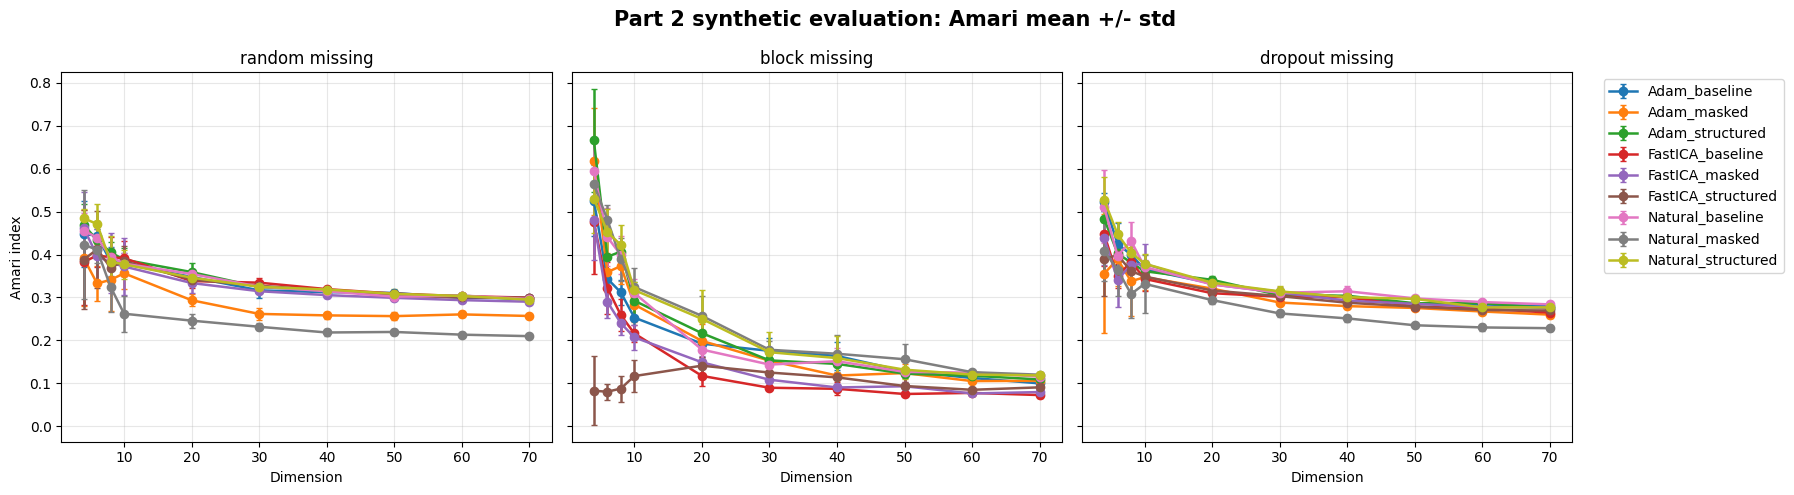

In [ ]:
# =========================
# Synthetic summaries
# =========================

# 1) Best method for each missingness pattern (keep unchanged)
pattern_summary = part2_synth_df.groupby(["Pattern", "Method", "Solver", "Variant"], as_index=False).agg(Mean_Amari=("Mean_Amari", "mean"), Std_Amari=("Mean_Amari", "std"), Mean_Time=("Mean_Time", "mean")).sort_values(["Pattern", "Mean_Amari", "Mean_Time"])
best_by_pattern = pattern_summary.groupby("Pattern", as_index=False).first()
display(best_by_pattern)

# 2) Best method by pattern and dimension regime (low / high)
dims = sorted(part2_synth_df["Dimension"].unique())
mid = len(dims) // 2
low_dims = dims[:mid]
high_dims = dims[mid:]

df_regime = part2_synth_df.copy()
df_regime["Dim_Regime"] = np.where(df_regime["Dimension"].isin(low_dims), "low", "high")

regime_summary = df_regime.groupby(["Pattern", "Dim_Regime", "Method", "Solver", "Variant"], as_index=False).agg(Mean_Amari=("Mean_Amari", "mean"), Std_Amari=("Mean_Amari", "std"), Mean_Time=("Mean_Time", "mean")).sort_values(["Pattern", "Dim_Regime", "Mean_Amari", "Mean_Time"])
best_by_pattern_regime = regime_summary.groupby(["Pattern", "Dim_Regime"], as_index=False).first()
display(best_by_pattern_regime)

top_methods_for_eeg = best_by_pattern_regime["Method"].drop_duplicates().tolist()

# =========================
# Dimension-sweep figures
# =========================
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, pattern in zip(axes, PART2_PATTERNS):
    sub = part2_synth_df[part2_synth_df["Pattern"] == pattern].copy()
    for method in sorted(sub["Method"].unique()):
        cur = sub[sub["Method"] == method].sort_values("Dimension")
        ax.errorbar(cur["Dimension"], cur["Mean_Amari"], yerr=cur["Std_Amari"], marker="o", linewidth=1.8, capsize=2, label=method)
    ax.set_title(f"{pattern} missing")
    ax.set_xlabel("Dimension")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Amari index")
axes[-1].legend(bbox_to_anchor=(1.05, 1.0), loc="upper left")
fig.suptitle("Part 2 synthetic evaluation: Amari mean +/- std", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

### Discussion of synthetic missing-data results

The synthetic benchmark shows that the best method depends mainly on the missingness pattern, while the ranking is relatively stable from low to high dimensions.

| Missingness pattern | Low dimensions | Low alternative | High dimensions | High alternative |
|---------------------|---------------|-----------------|-----------------|------------------|
| Random missing      | Natural_masked | Adam_masked     | Natural_masked  | Adam_masked      |
| Block missing       | FastICA_structured | FastICA_masked | FastICA_baseline | FastICA_masked  |
| Dropout missing     | Natural_masked | Adam_masked     | Natural_masked  | Adam_masked      |


### Single-case synthetic illustration (`dim = 4`)

Besides the original **low-dimensional / high-dimensional synthetic benchmark** above, we also include one explicit visualization requested for the report.

We now:
1. choose one generated mixture with `dim = 4`;
2. apply the three missingness patterns (`random`, `block`, `dropout`);
3. run **FastICA with the structured preprocessing**;
4. compare the **complete mixed signals**, the **masked / missing signals**, and the **separated signals**.

In [ ]:
# =========================
# Additional Part 2 synthetic demo helpers (dim = 4)
# =========================
PART2_DEMO_DIM = 4  # Demonstration dimension used for the single-case visualization.
PART2_DEMO_SEED = 123

def fastica_structured_demo(X_missing: np.ndarray, M: np.ndarray, pattern: str, seed: int = 0):
    X_white, whitening, mean_vec, M_white = preprocess_variant(X_missing, M, pattern, variant="structured")
    result = run_solver_variant("FastICA", "structured", X_white, M_white, seed)
    return {
        "result": result,
        "whitening": whitening,
        "mean_vec": mean_vec,
        "M_white": M_white,
    }

def best_match_permutation(Y: np.ndarray, S_ref: np.ndarray):
    corr = np.corrcoef(Y, S_ref)[:Y.shape[0], Y.shape[0]:]
    abs_corr = np.abs(corr)
    pairs = []
    used_rows = set()
    used_cols = set()

    flat_order = np.dstack(np.unravel_index(np.argsort(abs_corr.ravel())[::-1], abs_corr.shape))[0]
    for r, c in flat_order:
        r, c = int(r), int(c)
        if r not in used_rows and c not in used_cols:
            pairs.append((r, c))
            used_rows.add(r)
            used_cols.add(c)
        if len(pairs) == min(Y.shape[0], S_ref.shape[0]):
            break

    Y_aligned = np.zeros_like(S_ref[:len(pairs)])
    order = []
    for j, (r, c) in enumerate(sorted(pairs, key=lambda x: x[1])):
        sign = np.sign(corr[r, c]) if corr[r, c] != 0 else 1.0
        Y_aligned[j] = sign * Y[r]
        order.append((r, c, sign))
    return Y_aligned, order, corr

synthetic_demo_S, synthetic_demo_A, synthetic_demo_X = generate_part2_mixture(PART2_DEMO_DIM, seed=PART2_DEMO_SEED)
synthetic_demo_cases = {}

for pattern in PART2_PATTERNS:
    M = make_missing_mask(
        synthetic_demo_X.shape,
        pattern=pattern,
        missing_rate=PART2_MISSING_RATE,
        seed=PART2_DEMO_SEED + 10 + len(pattern)
    )
    X_missing = apply_mask(synthetic_demo_X, M)
    out = fastica_structured_demo(X_missing, M, pattern=pattern, seed=PART2_DEMO_SEED)
    Y_aligned, order, corr_mat = best_match_permutation(out["result"].Y, synthetic_demo_S)

    mean_abs_corr = float(np.mean([
        abs(np.corrcoef(Y_aligned[k], synthetic_demo_S[k])[0, 1])
        for k in range(PART2_DEMO_DIM)
    ]))
    amari = amari_index(out["result"].W @ out["whitening"], synthetic_demo_A)

    synthetic_demo_cases[pattern] = {
        "M": M,
        "X_missing": X_missing,
        "result": out["result"],
        "Y_aligned": Y_aligned,
        "order": order,
        "mean_abs_source_corr": mean_abs_corr,
        "amari": amari,
    }

synthetic_demo_summary = pd.DataFrame([
    {
        "Pattern": pattern,
        "ObservedRatio": case["M"].mean(),
        "MeanAbsCorr(separated,true)": case["mean_abs_source_corr"],
        "Amari": case["amari"],
    }
    for pattern, case in synthetic_demo_cases.items()
]).sort_values("Pattern")

display(synthetic_demo_summary)

,Pattern,ObservedRatio,"MeanAbsCorr(separated,true)",Amari
1,block,0.783500,0.739716,0.211700
2,dropout,0.779625,0.417155,0.308712
0,random,0.797375,0.378029,0.404317


This table compares source separation performance under three missing-data patterns with an effective missing rate close to 20%.
The ObservedRatio indicates the proportion of observed entries, so the corresponding missing rate is approximately 1 - ObservedRatio.
The results show that block and dropout missingness lead to better separation quality than random missingness, while random missingness is the most challenging setting.

In addition, as the dimension increases, the Amari index under random missingness tends to decrease. It is relatively larger in low-dimensional settings, but becomes smaller in higher-dimensional experiments. For instance, in the dim = 100 case, the Amari value for random missingness decreases to 0.284, i.e. below 0.3. This suggests that, under random missingness, the separation error becomes smaller as the dimension grows, which further supports the stability of the method in higher-dimensional settings.

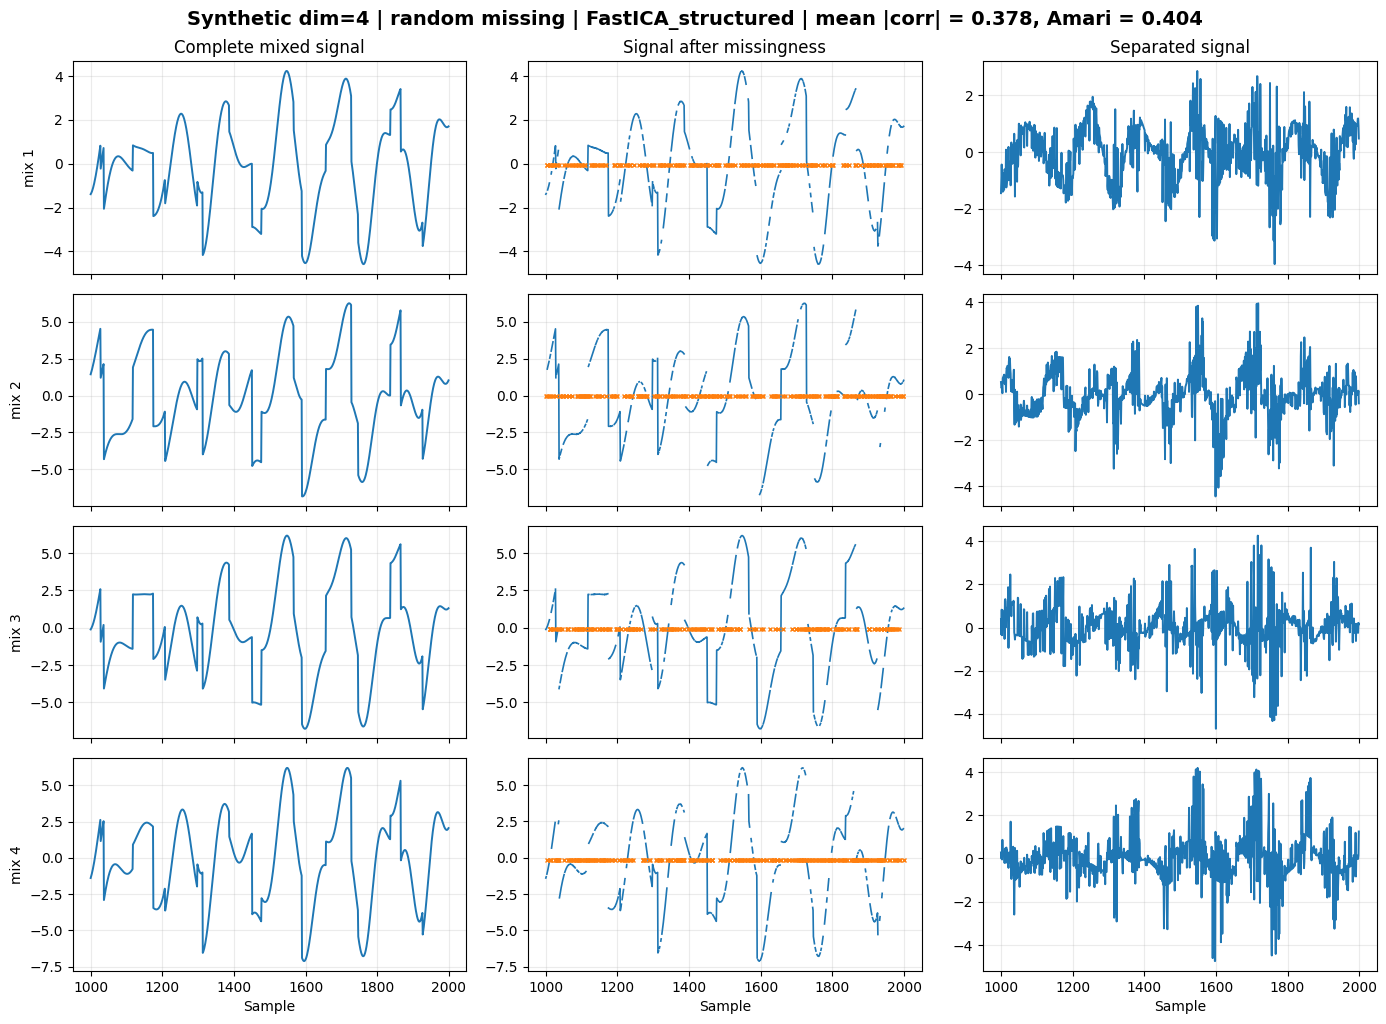

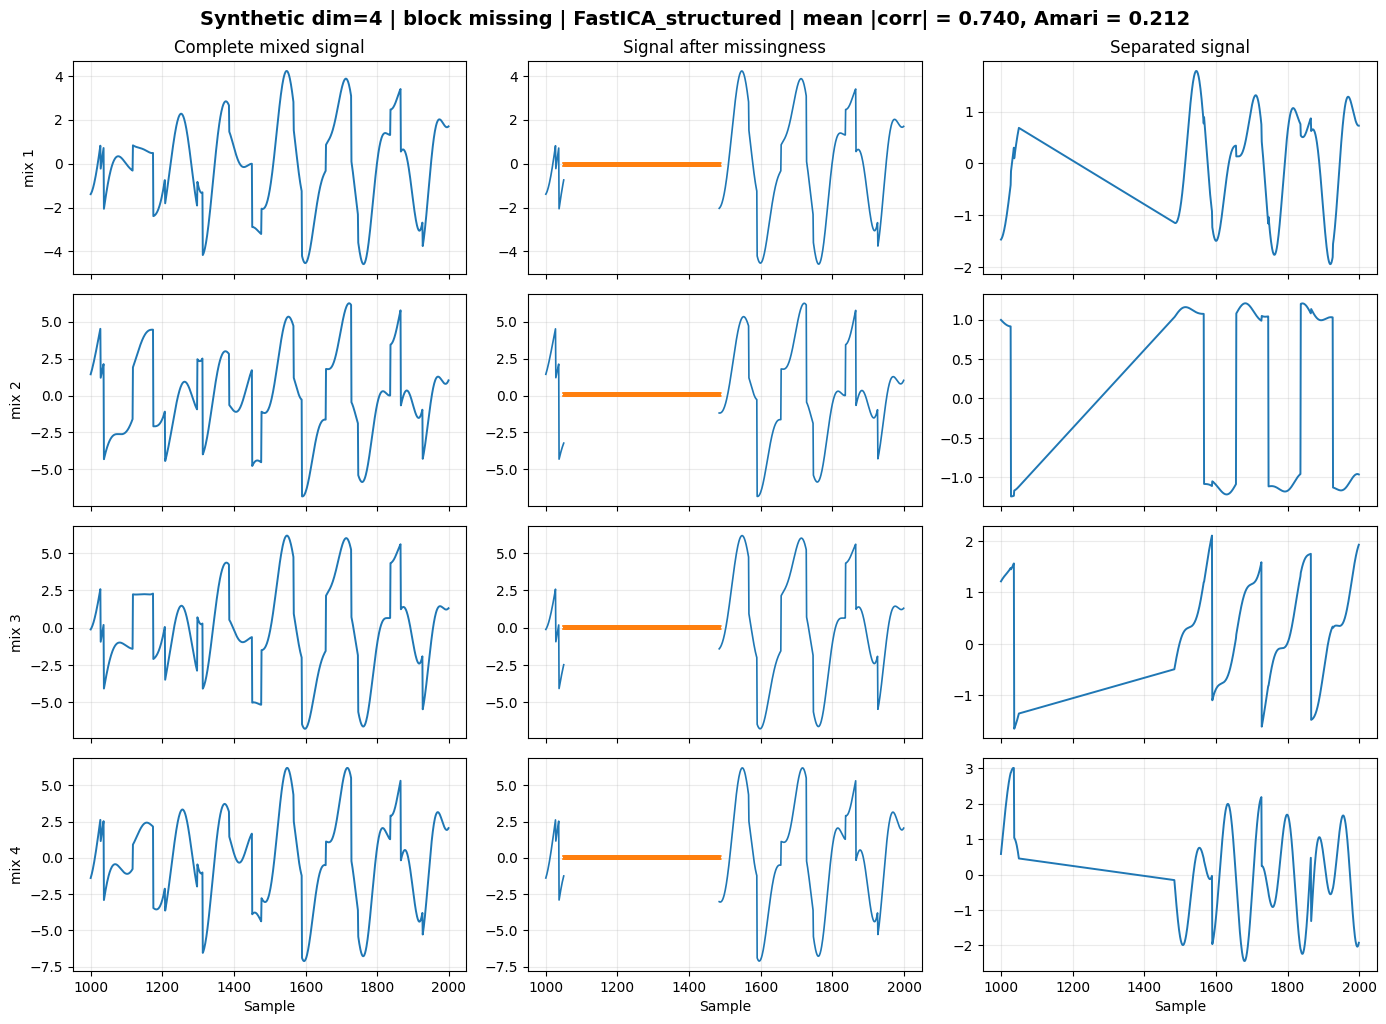

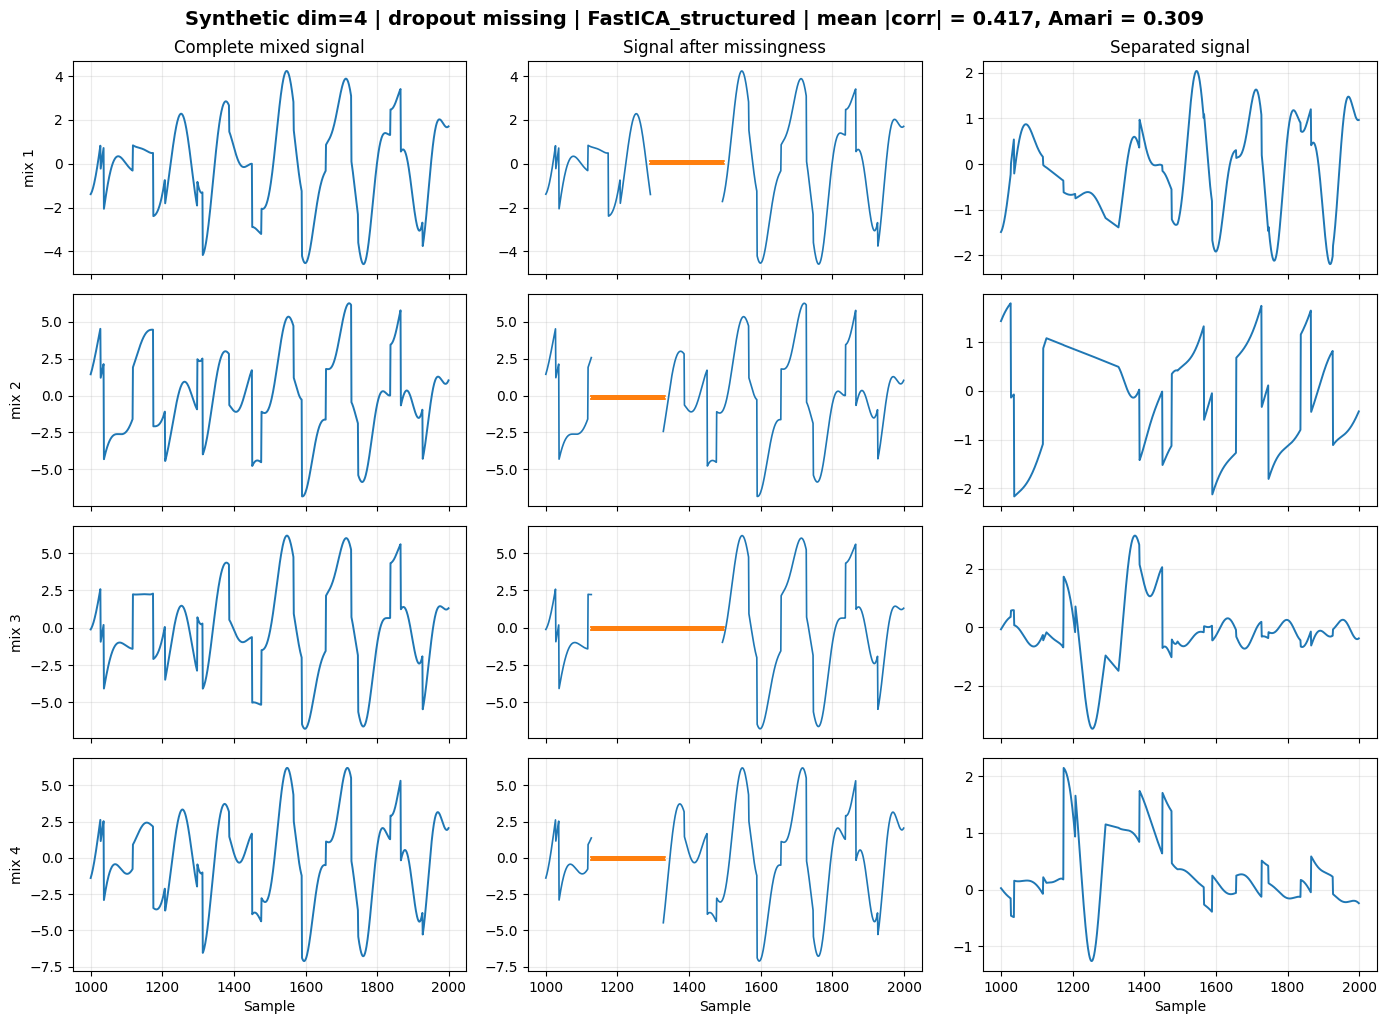

In [ ]:
# =========================
# Synthetic visualization: complete / missing / separated
# =========================
plot_window = slice(1000, 2000)
t_syn = np.arange(synthetic_demo_X.shape[1])[plot_window]

for pattern in PART2_PATTERNS:
    case = synthetic_demo_cases[pattern]
    X_missing = case["X_missing"]
    Y_aligned = case["Y_aligned"]

    fig, axes = plt.subplots(PART2_DEMO_DIM, 3, figsize=(14, 2.6 * PART2_DEMO_DIM), sharex=True)
    fig.suptitle(f"Synthetic dim=4 | {pattern} missing | FastICA_structured | mean |corr| = {case['mean_abs_source_corr']:.3f}, Amari = {case['amari']:.3f}", fontsize=14, fontweight="bold")

    for k in range(PART2_DEMO_DIM):
        axes[k, 0].plot(t_syn, synthetic_demo_X[k, plot_window], linewidth=1.4)
        axes[k, 0].set_ylabel(f"mix {k+1}")
        axes[k, 0].grid(alpha=0.25)
        if k == 0: axes[k, 0].set_title("Complete mixed signal")

        y_missing = X_missing[k, plot_window].copy()
        axes[k, 1].plot(t_syn, np.nan_to_num(y_missing, nan=np.nan), linewidth=1.2)
        miss_idx = np.where(np.isnan(y_missing))[0]
        if len(miss_idx) > 0:
            baseline = np.nanmean(np.nan_to_num(y_missing, nan=0.0))
            axes[k, 1].plot(t_syn[miss_idx], np.full_like(miss_idx, baseline, dtype=float), linestyle="None", marker="x", markersize=3)
        axes[k, 1].grid(alpha=0.25)
        if k == 0: axes[k, 1].set_title("Signal after missingness")

        axes[k, 2].plot(t_syn, Y_aligned[k, plot_window], linewidth=1.4)
        axes[k, 2].grid(alpha=0.25)
        if k == 0: axes[k, 2].set_title("Separated signal")

    axes[-1, 0].set_xlabel("Sample")
    axes[-1, 1].set_xlabel("Sample")
    axes[-1, 2].set_xlabel("Sample")
    plt.tight_layout()
    plt.show()

### Missing-rate sensitivity study
We further investigate the effect of missing rate on source separation performance.
For dim=4, we use FastICA_structured; for dim=60, we use Natural_masked.
The missing rate varies from 10% to 50%. We report mean absolute correlation between recovered and true sources, as well as the Amari index.

,dim,pattern,method,missing_rate,observed_ratio_mean,amari_mean,amari_std
0,4,block,FastICA_structured,0.1,0.837000,0.083563,0.051694
1,4,block,FastICA_structured,0.2,0.764100,0.116098,0.064603
2,4,block,FastICA_structured,0.3,0.664700,0.104409,0.072110
3,4,block,FastICA_structured,0.4,0.571000,0.183737,0.096605
4,4,block,FastICA_structured,0.5,0.465800,0.278672,0.122826
5,4,dropout,FastICA_structured,0.1,0.883450,0.333347,0.089965
6,4,dropout,FastICA_structured,0.2,0.782675,0.369613,0.086802
7,4,dropout,FastICA_structured,0.3,0.676425,0.413596,0.042453
8,4,dropout,FastICA_structured,0.4,0.578800,0.386109,0.044510
9,4,dropout,FastICA_structured,0.5,0.473400,0.426326,0.060877


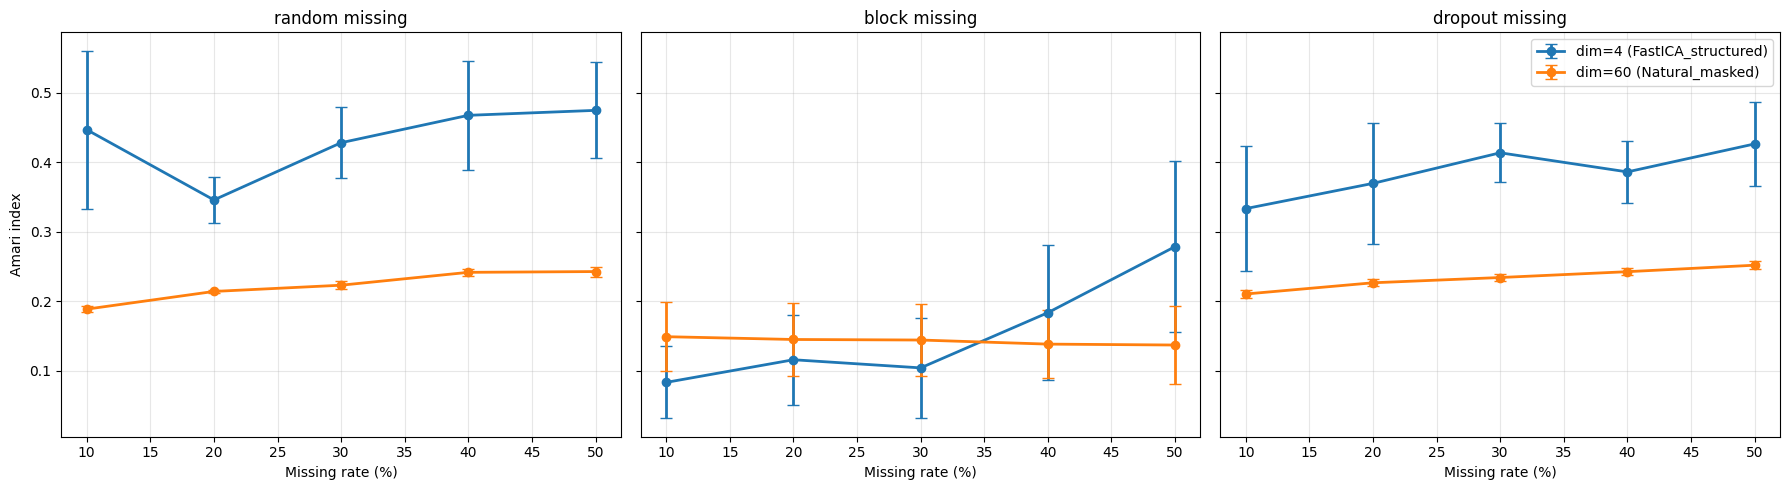

In [ ]:
# =========================
# Missing-rate sensitivity analysis
# dim = 4  -> FastICA_structured
# dim = 60 -> Natural_masked
# =========================

MISSING_RATES = [0.1, 0.2, 0.3, 0.4, 0.5]
PATTERNS_FOR_RATE_STUDY = ["random", "block", "dropout"]
SEEDS_FOR_RATE_STUDY = [2026, 2027, 2028, 2029, 2030]

def run_missing_rate_experiment_amari_only(dim, missing_rates, seeds, patterns, solver_name="FastICA", variant="structured"):
    records = []
    for seed in seeds:
        S_true, A_true, X_complete = generate_part2_mixture(dim, seed=seed)
        for pattern in patterns:
            for mr in missing_rates:
                M = make_missing_mask(X_complete.shape, pattern=pattern, missing_rate=mr, seed=seed + int(mr * 1000) + dim + len(pattern))
                X_missing = apply_mask(X_complete, M)
                X_white, whitening, mean_vec, M_white = preprocess_variant(X_missing, M, pattern, variant=variant)
                result = run_solver_variant(solver_name, variant, X_white, M_white, seed)
                records.append({"seed": seed, "dim": dim, "pattern": pattern, "method": f"{solver_name}_{variant}", "missing_rate": mr, "observed_ratio": M.mean(), "amari": float(amari_index(result.W @ whitening, A_true))})
    df = pd.DataFrame(records)
    summary = df.groupby(["dim", "pattern", "method", "missing_rate"], as_index=False).agg(observed_ratio_mean=("observed_ratio", "mean"), amari_mean=("amari", "mean"), amari_std=("amari", "std"))
    return df, summary

def summarize_missing_rate_case(dim, solver_name, variant):
    return run_missing_rate_experiment_amari_only(dim=dim, missing_rates=MISSING_RATES, seeds=SEEDS_FOR_RATE_STUDY, patterns=PATTERNS_FOR_RATE_STUDY, solver_name=solver_name, variant=variant)

# Case A: dim = 4 with FastICA_structured
rate_raw_dim4, rate_summary_dim4 = summarize_missing_rate_case(dim=4, solver_name="FastICA", variant="structured")

# Case B: dim = 60 with Natural_masked
rate_raw_dim60, rate_summary_dim60 = summarize_missing_rate_case(dim=60, solver_name="Natural", variant="masked")

rate_summary_all = pd.concat([rate_summary_dim4, rate_summary_dim60], ignore_index=True)
display(rate_summary_all)

# =========================
# Visualization: Amari vs missing rate
# =========================
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, pattern in zip(axes, PATTERNS_FOR_RATE_STUDY):
    sub = rate_summary_all[rate_summary_all["pattern"] == pattern].copy()
    for dim_val, df_sub in sub.groupby("dim"):
        df_sub = df_sub.sort_values("missing_rate")
        ax.errorbar(df_sub["missing_rate"] * 100, df_sub["amari_mean"], yerr=df_sub["amari_std"], marker="o", linewidth=2, capsize=4, label=f"dim={dim_val} ({df_sub['method'].iloc[0]})")
    ax.set_title(f"{pattern} missing")
    ax.set_xlabel("Missing rate (%)")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Amari index")
axes[-1].legend()
plt.tight_layout()
plt.show()

From the figure, the Amari index remains relatively stable as the missing rate increases from 10% to 50%. For dim = 4 (FastICA_structured), the Amari index varies roughly between 0.08 and 0.48 across the three missing patterns. For dim = 60 (Natural_masked), the range is narrower, approximately 0.14 to 0.25. Overall, although the missing rate increases, the fluctuations remain moderate and no drastic degradation is observed, indicating that the methods maintain reasonably stable separation performance under different levels of missing data

<a id="EEG-transfer-study"></a>

### EEG transfer study

**Task.** Test whether the synthetic ranking transfers to a real EEG denoising task.

Protocol:
1. load EEG together with an EOG reference channel;
2. artificially impose random, block, or dropout missingness on the EEG channels;
3. run 9 methods;
4. evaluate whether the method can identify a blink-related component and reduce EEG–EOG coupling after artifact removal.

This section moves from exact source-recovery metrics to practical artifact-removal metrics on real data.


In [ ]:
%pip install mne


In [ ]:

# If needed, uncomment the next line:
# %pip install mne requests

import os
import tarfile
from pathlib import Path

import requests
import mne
from mne.datasets import sample
from mne.preprocessing import find_eog_events


### EEG analysis protocol around a complete-data EOG reference

The EEG subsection is reorganized to follow the requested logic:

1. load the complete EEG and EOG channels;
2. run **FastICA on the complete EEG**;
3. identify the EOG-related IC using several indicators and keep its **reference index**;
4. impose the three missingness patterns on the complete EEG;
5. recover ICs with the 9 strategy;
6. compare the recovered EOG-like ICs with the reference EOG IC extracted from complete data.

This way, the complete-data decomposition is the common reference for all missing-data comparisons.

### Identification of the EOG-related reference IC

To determine the EOG-related independent component (IC), we compute a composite score for each IC based on several indicators that measure its similarity to the EOG signal.

First, each IC time series $y_k(t)$ and the EOG signal $e(t)$ are standardized:

$$
z_k(t) = \frac{y_k(t) - \mu_k}{\sigma_k + \varepsilon},
\qquad
z_{\mathrm{EOG}}(t) = \frac{e(t) - \mu_{\mathrm{EOG}}}{\sigma_{\mathrm{EOG}} + \varepsilon}
$$

where $\varepsilon$ is a small constant to avoid division by zero.

We also compute the first-order differences:

$$
\Delta z_k(t) = z_k(t) - z_k(t-1),
\qquad
\Delta z_{\mathrm{EOG}}(t) = z_{\mathrm{EOG}}(t) - z_{\mathrm{EOG}}(t-1)
$$

For each IC $k$, we evaluate four indicators:

- Absolute correlation with the EOG signal  
- Absolute correlation with the derivative of the EOG signal  
- Excess kurtosis of the IC signal  
- Maximum absolute amplitude of the IC signal  

The excess kurtosis is defined as

$$
\text{kurt}(z_k) = \mathbb{E}[z_k^4] - 3
$$

A composite score is then computed:

$$
\text{Score}_k =
0.60\,|\mathrm{corr}(z_k, z_{\mathrm{EOG}})|
+
0.25\,|\mathrm{corr}(\Delta z_k, \Delta z_{\mathrm{EOG}})|
+
0.10\,\min\!\left(\frac{|\mathrm{kurt}(z_k)|}{10},\,1\right)
+
0.05\,\min\!\left(\frac{\max_t |z_k(t)|}{8},\,1\right)
$$

Finally, the IC with the highest score is selected as the **reference EOG-related IC**:

$$
k_{\mathrm{ref}} = \arg\max_k \text{Score}_k
$$

The index $k_{\mathrm{ref}}$ is stored as the **reference index**, and the corresponding IC signal is used as the reference component in the subsequent missing-data experiments.

In [ ]:
# =========================
# EEG helper functions for reordered comparison
# =========================
SAMPLE_ARCHIVE_URL = "https://osf.io/download/86qa2?version=6"
SAMPLE_ARCHIVE_NAME = "MNE-sample-data-processed.tar.gz"
SAMPLE_FOLDER_NAME = "MNE-sample-data"

EEG_ALL_METHODS = [
    ("FastICA", "baseline"), ("FastICA", "structured"), ("FastICA", "masked"),
    ("Adam", "baseline"), ("Adam", "structured"), ("Adam", "masked"),
    ("Natural", "baseline"), ("Natural", "structured"), ("Natural", "masked"),
]
def _safe_corr(x: np.ndarray, y: np.ndarray) -> float:
    x = np.asarray(x).ravel(); y = np.asarray(y).ravel()
    if np.std(x) < 1e-10 or np.std(y) < 1e-10: return 0.0
    return float(np.corrcoef(x, y)[0, 1])

def identify_eog_reference_ic(Y: np.ndarray, eog: np.ndarray):
    rows = []; eog_z = (eog - np.mean(eog)) / (np.std(eog) + 1e-8); eog_diff = np.diff(eog_z, prepend=eog_z[0])
    for k in range(Y.shape[0]):
        y = Y[k]; y_z = (y - np.mean(y)) / (np.std(y) + 1e-8)
        corr = _safe_corr(y_z, eog_z); corr_diff = _safe_corr(np.diff(y_z, prepend=y_z[0]), eog_diff)
        kurt = float(np.mean(y_z ** 4) - 3.0); peak = float(np.max(np.abs(y_z)))
        score = 0.60 * abs(corr) + 0.25 * abs(corr_diff) + 0.10 * min(abs(kurt) / 10.0, 1.0) + 0.05 * min(peak / 8.0, 1.0)
        rows.append({"IC": k, "AbsCorrWithEOG": abs(corr), "AbsCorrDerivativeWithEOG": abs(corr_diff), "KurtosisExcess": kurt, "PeakAbsZ": peak, "CompositeScore": score})
    metrics_df = pd.DataFrame(rows).sort_values(["CompositeScore", "AbsCorrWithEOG", "AbsCorrDerivativeWithEOG"], ascending=False).reset_index(drop=True)
    best_ic = int(metrics_df.loc[0, "IC"])
    return best_ic, metrics_df

def extract_top_non_eog(metrics_df: pd.DataFrame, eog_idx: int, n_keep: int = 2):
    return [int(x) for x in metrics_df.loc[metrics_df["IC"] != eog_idx, "IC"].tolist()[:n_keep]]

def ensure_mne_sample_dataset(path: Optional[str] = None, timeout=(30, 600), chunk_size=2**20) -> str:
    base = Path(path) if path is not None else Path.home() / "mne_data"; base.mkdir(parents=True, exist_ok=True)
    sample_root = base / SAMPLE_FOLDER_NAME
    expected_fif = sample_root / "MEG" / "sample" / "sample_audvis_filt-0-40_raw.fif"
    if expected_fif.exists(): return str(base)
    archive_path = base / SAMPLE_ARCHIVE_NAME
    if not archive_path.exists():
        with requests.get(SAMPLE_ARCHIVE_URL, stream=True, timeout=timeout) as r:
            r.raise_for_status()
            with open(archive_path, "wb") as f:
                for chunk in r.iter_content(chunk_size=chunk_size):
                    if chunk: f.write(chunk)
    with tarfile.open(archive_path, "r:gz") as tar: tar.extractall(path=base)
    return str(base)

def load_mne_sample_eeg(duration_sec: float = 60.0, n_eeg_use: int = 20) -> Dict[str, np.ndarray]:
    data_path = ensure_mne_sample_dataset()
    raw_path = os.path.join(data_path, "MEG", "sample", "sample_audvis_filt-0-40_raw.fif")
    if not os.path.exists(raw_path): raw_path = os.path.join(data_path, "MNE-sample-data", "MEG", "sample", "sample_audvis_filt-0-40_raw.fif")
    raw = mne.io.read_raw_fif(raw_path, preload=True, verbose=False)
    raw.crop(tmin=0.0, tmax=duration_sec); raw.pick(["eeg", "eog"]); raw.filter(l_freq=1.0, h_freq=40.0, verbose=False)
    sfreq = raw.info["sfreq"]; eeg_picks = mne.pick_types(raw.info, eeg=True, eog=False); eog_picks = mne.pick_types(raw.info, eeg=False, eog=True)
    X_eeg_full = raw.get_data(picks=eeg_picks); eog = raw.get_data(picks=eog_picks)[0]; eeg_names_full = [raw.ch_names[p] for p in eeg_picks]
    eeg_corrs = np.array([abs(_safe_corr(ch, eog)) for ch in X_eeg_full]); sel = np.argsort(eeg_corrs)[::-1][:n_eeg_use]
    events = find_eog_events(raw, ch_name=raw.ch_names[eog_picks[0]], verbose=False)
    return {"X_eeg": X_eeg_full[sel], "eog": eog, "sfreq": sfreq, "eeg_names": [eeg_names_full[i] for i in sel], "blink_samples": events[:, 0]}

def compare_ic_to_reference(y_candidate: np.ndarray, y_reference: np.ndarray, eog: np.ndarray):
    y1 = (y_candidate - np.mean(y_candidate)) / (np.std(y_candidate) + 1e-8); y2 = (y_reference - np.mean(y_reference)) / (np.std(y_reference) + 1e-8)
    same = _safe_corr(y1, y2); flip = _safe_corr(-y1, y2); sign = 1.0 if abs(same) >= abs(flip) else -1.0; y1_aligned = sign * y1
    return {"SignUsed": sign, "AbsCorrWithReferenceIC": abs(_safe_corr(y1_aligned, y2)), "RMSE_to_ReferenceIC": float(np.sqrt(np.mean((y1_aligned - y2) ** 2))), "AbsCorrWithEOG": abs(_safe_corr(y1_aligned, eog)), "ReferenceIC_AbsCorrWithEOG": abs(_safe_corr(y2, eog)), "DeltaAbsCorrToEOG": abs(abs(_safe_corr(y1_aligned, eog)) - abs(_safe_corr(y2, eog))), "AlignedSignal": y1_aligned, "ReferenceSignal": y2}

def _reconstruct_from_ica(result: ICAResult, X_observed: np.ndarray, exclude_idx: int, ridge: float = 1e-6) -> np.ndarray:
    Y = result.Y.copy(); Y[exclude_idx] = 0.0
    Y_full = result.Y; n_comp, n_times = Y.shape; n_ch = X_observed.shape[0]
    A = np.zeros((n_ch, n_comp)); mu = np.zeros((n_ch, 1)); G = Y_full @ Y_full.T + ridge * np.eye(n_comp); Ginv = np.linalg.pinv(G)
    for i in range(n_ch):
        x_i = X_observed[i]; mu_i = np.mean(x_i); mu[i, 0] = mu_i; x_centered = x_i - mu_i; A[i] = (x_centered @ Y_full.T) @ Ginv
    return A @ Y + mu

def run_single_eeg_ica_method(X_missing: np.ndarray, M: np.ndarray, pattern: str, solver: str, variant: str, seed: int = 0):
    X_white, whitening, mean_vec, M_white = preprocess_variant(X_missing, M, pattern, variant)
    result = run_solver_variant(solver, variant, X_white, M_white, seed)
    return {"pattern": pattern, "method": f"{solver}_{variant}", "solver": solver, "variant": variant, "M": M, "X_missing": X_missing, "X_for_reconstruction": np.nan_to_num(X_missing, nan=0.0), "X_white": X_white, "whitening": whitening, "mean_vec": mean_vec, "result": result}

def run_pattern_specific_eeg_ica(X_eeg: np.ndarray, eog: np.ndarray, pattern: str, seed: int = 0, methods=EEG_ALL_METHODS):
    M = make_missing_mask(X_eeg.shape, pattern=pattern, missing_rate=PART2_MISSING_RATE, seed=seed + 2000); X_missing = apply_mask(X_eeg, M)
    return [run_single_eeg_ica_method(X_missing, M, pattern, solver, variant, seed) for solver, variant in methods]

def run_all_patterns_all_methods(X_eeg: np.ndarray, eog: np.ndarray, patterns=("random", "dropout", "block"), seed: int = 0, methods=EEG_ALL_METHODS):
    return {pattern: run_pattern_specific_eeg_ica(X_eeg, eog, pattern, seed=seed, methods=methods) for pattern in patterns}

def find_best_matching_ic(result: ICAResult, y_reference: np.ndarray, eog: np.ndarray):
    rows = []
    for k in range(result.Y.shape[0]):
        comp = compare_ic_to_reference(result.Y[k], y_reference, eog)
        rows.append({"IC": k, "AbsCorrWithReferenceIC": comp["AbsCorrWithReferenceIC"], "RMSE_to_ReferenceIC": comp["RMSE_to_ReferenceIC"], "AbsCorrWithEOG": comp["AbsCorrWithEOG"], "DeltaAbsCorrToEOG": comp["DeltaAbsCorrToEOG"], "SignUsed": comp["SignUsed"], "AlignedSignal": comp["AlignedSignal"], "ReferenceSignal": comp["ReferenceSignal"]})
    df = pd.DataFrame(rows).sort_values(["AbsCorrWithReferenceIC", "AbsCorrWithEOG"], ascending=[False, False]).reset_index(drop=True)
    best_ic = int(df.loc[0, "IC"])
    return best_ic, df

def evaluate_eeg_case(case: dict, y_reference: np.ndarray, eog: np.ndarray):
    best_ic, match_df = find_best_matching_ic(case["result"], y_reference, eog)
    best_row = match_df.iloc[0].to_dict()
    return {"pattern": case["pattern"], "method": case["method"], "solver": case["solver"], "variant": case["variant"], "best_ic": best_ic, "match_df": match_df, "metrics": best_row, "case": case}

def evaluate_all_eeg_cases(eeg_cases: dict, y_reference: np.ndarray, eog: np.ndarray):
    rows = []; detailed = {}
    for pattern, cases in eeg_cases.items():
        detailed[pattern] = []
        for case in cases:
            out = evaluate_eeg_case(case, y_reference, eog); detailed[pattern].append(out)
            rows.append({"pattern": out["pattern"], "method": out["method"], "solver": out["solver"], "variant": out["variant"], "best_ic": out["best_ic"], "AbsCorrWithReferenceIC": out["metrics"]["AbsCorrWithReferenceIC"], "RMSE_to_ReferenceIC": out["metrics"]["RMSE_to_ReferenceIC"], "AbsCorrWithEOG": out["metrics"]["AbsCorrWithEOG"], "DeltaAbsCorrToEOG": out["metrics"]["DeltaAbsCorrToEOG"]})
    summary_df = pd.DataFrame(rows).sort_values(["pattern", "AbsCorrWithReferenceIC", "AbsCorrWithEOG"], ascending=[True, False, False]).reset_index(drop=True)
    return summary_df, detailed

In [ ]:
# =========================
# Complete EEG reference decomposition
# =========================
eeg_data = load_mne_sample_eeg(duration_sec=60.0, n_eeg_use=70)
X_eeg = eeg_data["X_eeg"]
eog = eeg_data["eog"]
sfreq = eeg_data["sfreq"]
eeg_names = eeg_data["eeg_names"]

print(f"EEG data shape: {X_eeg.shape} (n_channels, n_samples)")
print(f"EOG data shape: {eog.shape}")
print(f"Sampling frequency: {sfreq} Hz")
print(f"Selected EEG channels ({len(eeg_names)}): {eeg_names}")

X_eeg_white, eeg_whitening, eeg_mean = preprocess(X_eeg)
eeg_full_result = fastica_baseline(X_eeg_white, random_state=0)

reference_eog_ic, full_metrics = identify_eog_reference_ic(eeg_full_result.Y, eog)
reference_non_eog = extract_top_non_eog(full_metrics, reference_eog_ic, n_keep=2)
reference_ic_signal = eeg_full_result.Y[reference_eog_ic]
ref_row = full_metrics[full_metrics["IC"] == reference_eog_ic].iloc[0]

print(f"ICA source matrix shape: {eeg_full_result.Y.shape} (n_components, n_samples)")
print(f"Reference EOG-related IC on complete EEG: IC #{reference_eog_ic}")
print(f"Reference IC signal shape: {reference_ic_signal.shape}")
print(f"Top non-EOG reference ICs: {reference_non_eog}")
print(f"Reference IC metrics: AbsCorrWithEOG={ref_row['AbsCorrWithEOG']:.4f}, AbsCorrDerivativeWithEOG={ref_row['AbsCorrDerivativeWithEOG']:.4f}, KurtosisExcess={ref_row['KurtosisExcess']:.4f}, PeakAbsZ={ref_row['PeakAbsZ']:.4f}, CompositeScore={ref_row['CompositeScore']:.4f}")

display(full_metrics.head(10))

EEG data shape: (59, 9010) (n_channels, n_samples)
EOG data shape: (9010,)
Sampling frequency: 150.15374755859375 Hz
Selected EEG channels (59): ['EEG 002', 'EEG 003', 'EEG 001', 'EEG 007', 'EEG 006', 'EEG 004', 'EEG 016', 'EEG 005', 'EEG 015', 'EEG 013', 'EEG 014', 'EEG 022', 'EEG 009', 'EEG 008', 'EEG 011', 'EEG 012', 'EEG 010', 'EEG 024', 'EEG 019', 'EEG 023', 'EEG 017', 'EEG 018', 'EEG 021', 'EEG 033', 'EEG 020', 'EEG 035', 'EEG 034', 'EEG 027', 'EEG 026', 'EEG 028', 'EEG 032', 'EEG 042', 'EEG 029', 'EEG 031', 'EEG 030', 'EEG 025', 'EEG 037', 'EEG 043', 'EEG 038', 'EEG 041', 'EEG 039', 'EEG 040', 'EEG 052', 'EEG 036', 'EEG 050', 'EEG 045', 'EEG 046', 'EEG 047', 'EEG 051', 'EEG 048', 'EEG 049', 'EEG 044', 'EEG 056', 'EEG 058', 'EEG 055', 'EEG 059', 'EEG 060', 'EEG 054', 'EEG 057']
ICA source matrix shape: (59, 9010) (n_components, n_samples)
Reference EOG-related IC on complete EEG: IC #40
Reference IC signal shape: (9010,)
Top non-EOG reference ICs: [58, 24]
Reference IC metrics: A

,IC,AbsCorrWithEOG,AbsCorrDerivativeWithEOG,KurtosisExcess,PeakAbsZ,CompositeScore
0,40,0.873201,0.464245,48.684014,13.439031,0.789982
1,58,0.008164,0.061405,6.573582,9.494844,0.135985
2,24,0.086846,0.102737,1.977899,6.039592,0.135318
3,42,0.091050,0.025038,0.426505,4.221326,0.091538
4,27,0.022042,0.058042,1.427281,6.145744,0.080419
5,17,0.022917,0.119980,0.267525,4.157691,0.072406
6,38,0.027071,0.055390,0.653091,5.099431,0.068492
7,12,0.002889,0.034761,1.747522,6.438857,0.068142
8,39,0.027201,0.095498,0.259037,4.001983,0.067798
9,0,0.035667,0.061091,0.134188,4.534872,0.066358


The ICA decomposition of the complete EEG data produced 59 independent components.
Using the composite scoring criterion, IC #40 was identified as the EOG-related component.
This component shows a strong correlation with the EOG signal (0.873), a high excess kurtosis (48.7), and large peak amplitude, which are characteristic signatures of eye-blink artifacts.
Therefore, IC #40 is selected as the reference component for the subsequent missing-data experiments.

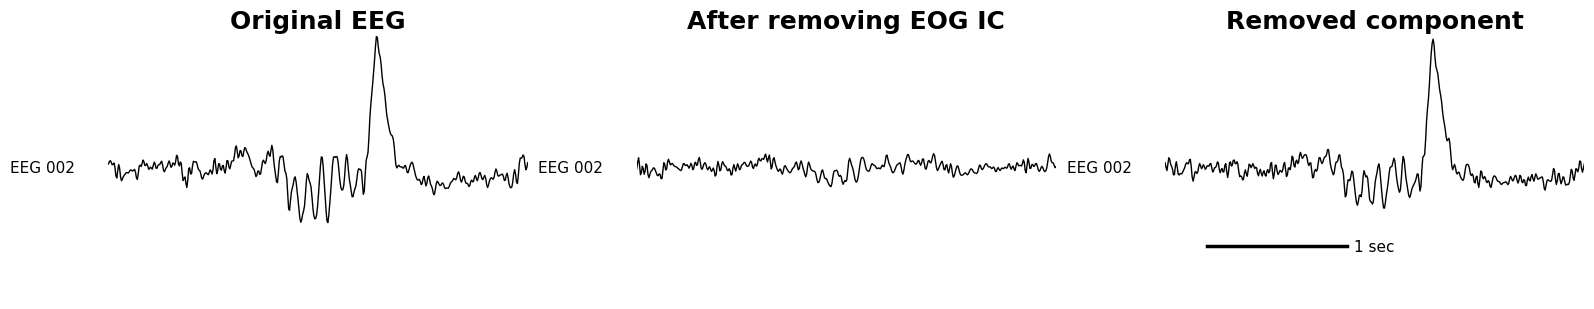

In [ ]:
# =========================
# Better visualization of EOG removal effect
# - choose blink-centered window
# - choose EEG channels most correlated with EOG
# - use SAME scale before/after
# - add difference plot
# =========================
# 1) Choose a window centered on one blink
if "blink_samples" in eeg_data and len(eeg_data["blink_samples"]) > 0:
    center = int(eeg_data["blink_samples"][0])
else:
    center = int(5.0 * sfreq)

half_window_sec = 1.5
half_w = int(half_window_sec * sfreq)
start = max(0, center - half_w)
end = min(X_eeg.shape[1], center + half_w)
t = np.arange(start, end) / sfreq

# 2) Choose EEG channels most correlated with EOG
channel_corrs = np.array([abs(_safe_corr(X_eeg[k], eog)) for k in range(X_eeg.shape[0])])
top_idx = np.argsort(channel_corrs)[::-1][:6]
top_names = [eeg_names[i] for i in top_idx]

# ---- 3) reconstruct EEG after removing the reference EOG IC
Y_full = eeg_full_result.Y.copy()
W_full = eeg_full_result.W.copy()

Y_no_eog = Y_full.copy()
Y_no_eog[reference_eog_ic, :] = 0.0

X_white_rec = np.linalg.pinv(W_full) @ Y_no_eog
X_reconstructed_no_eog = np.linalg.pinv(eeg_whitening) @ X_white_rec + eeg_mean

# removed part
X_removed = X_eeg - X_reconstructed_no_eog

# 4) Build stacked plots with a shared amplitude scale
def stacked_plot(ax, X, ch_idx, ch_names, t, start, end, title, scale=None):
    seg = X[ch_idx, start:end]
    if scale is None: scale = np.max(np.abs(seg)) + 1e-8
    offsets = np.arange(len(ch_idx), 0, -1)
    for i, (idx, name) in enumerate(zip(ch_idx, ch_names)):
        y = seg[i] / scale + offsets[i]
        ax.plot(t, y, color="black", linewidth=1.0)
        ax.text(t[0] - 0.08 * (t[-1] - t[0]), offsets[i], name, ha="right", va="center", fontsize=11)
    ax.set_title(title, fontsize=18, fontweight="bold")
    ax.set_xlim(t[0], t[-1])
    ax.set_ylim(0, len(ch_idx) + 1)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values(): spine.set_visible(False)
    return scale

# 只显示第一行
show_idx = top_idx[:1]
show_names = top_names[:1]

global_scale = max(np.max(np.abs(X_eeg[show_idx, start:end])), np.max(np.abs(X_reconstructed_no_eog[show_idx, start:end])), np.max(np.abs(X_removed[show_idx, start:end]))) + 1e-8

fig, axes = plt.subplots(1, 3, figsize=(16, 3.2))

stacked_plot(axes[0], X_eeg, show_idx, show_names, t, start, end, title="Original EEG", scale=global_scale)
stacked_plot(axes[1], X_reconstructed_no_eog, show_idx, show_names, t, start, end, title="After removing EOG IC", scale=global_scale)
stacked_plot(axes[2], X_removed, show_idx, show_names, t, start, end, title="Removed component", scale=global_scale)

bar_len = 1.0
x0 = t[0] + 0.1 * (t[-1] - t[0])
x1 = x0 + bar_len
ybar = 0.4
axes[2].plot([x0, x1], [ybar, ybar], color="black", linewidth=2.5)
axes[2].text(x1 + 0.05, ybar, "1 sec", va="center", fontsize=11)

plt.tight_layout()
plt.show()

In [ ]:
# =========================
# Repeated EEG experiments across multiple seeds for stability
# =========================
seeds=[0,1,2,3,4]; eeg_cases={}; comparison_rows=[]

for pattern in PART2_PATTERNS:
    eeg_cases[pattern]={}
    for seed in seeds:
        cases=run_pattern_specific_eeg_ica(X_eeg,eog,pattern=pattern,seed=seed); eeg_cases[pattern][seed]=[]
        for case in cases:
            recovered_eog_ic,metrics_df=identify_eog_reference_ic(case["result"].Y,eog); recovered_non_eog=extract_top_non_eog(metrics_df,recovered_eog_ic,n_keep=2); comp=compare_ic_to_reference(case["result"].Y[recovered_eog_ic],reference_ic_signal,eog)
            X_clean=_reconstruct_from_ica(case["result"],case["X_for_reconstruction"],exclude_idx=recovered_eog_ic); residual_ratio=np.mean([abs(_safe_corr(ch,eog)) for ch in X_clean])/(np.mean([abs(_safe_corr(ch,eog)) for ch in X_eeg])+1e-8)
            case.update({"seed":seed,"metrics_df":metrics_df,"recovered_eog_ic":recovered_eog_ic,"recovered_non_eog":recovered_non_eog,"comparison":comp,"X_clean":X_clean,"residual_ratio":residual_ratio}); eeg_cases[pattern][seed].append(case)
            comparison_rows.append({"Seed":seed,"Pattern":pattern,"Method":case["method"],"Solver":case["solver"],"Variant":case["variant"],"RecoveredEOG_IC":recovered_eog_ic,"ReferenceEOG_IC":reference_eog_ic,"AbsCorrWithReferenceIC":comp["AbsCorrWithReferenceIC"],"RMSE_to_ReferenceIC":comp["RMSE_to_ReferenceIC"],"RecoveredAbsCorrWithEOG":comp["AbsCorrWithEOG"],"ReferenceAbsCorrWithEOG":comp["ReferenceIC_AbsCorrWithEOG"],"DeltaAbsCorrToEOG":comp["DeltaAbsCorrToEOG"],"ResidualEEGtoEOGCorrRatio":residual_ratio})

eeg_comparison_df=pd.DataFrame(comparison_rows).sort_values(["Pattern","Method","Seed"]).reset_index(drop=True); display(eeg_comparison_df)

# =========================
# Aggregate mean/std across seeds
# =========================
eeg_summary_df=eeg_comparison_df.groupby(["Pattern","Method","Solver","Variant"],as_index=False).agg(MeanAbsCorrWithReferenceIC=("AbsCorrWithReferenceIC","mean"),StdAbsCorrWithReferenceIC=("AbsCorrWithReferenceIC","std"),MeanRMSE_to_ReferenceIC=("RMSE_to_ReferenceIC","mean"),StdRMSE_to_ReferenceIC=("RMSE_to_ReferenceIC","std"),MeanRecoveredAbsCorrWithEOG=("RecoveredAbsCorrWithEOG","mean"),StdRecoveredAbsCorrWithEOG=("RecoveredAbsCorrWithEOG","std"),MeanDeltaAbsCorrToEOG=("DeltaAbsCorrToEOG","mean"),StdDeltaAbsCorrToEOG=("DeltaAbsCorrToEOG","std"),MeanResidualEEGtoEOGCorrRatio=("ResidualEEGtoEOGCorrRatio","mean"),StdResidualEEGtoEOGCorrRatio=("ResidualEEGtoEOGCorrRatio","std"))

eeg_summary_df=eeg_summary_df.sort_values(["Pattern","MeanAbsCorrWithReferenceIC","MeanRMSE_to_ReferenceIC","MeanResidualEEGtoEOGCorrRatio"],ascending=[True,False,True,True]).reset_index(drop=True); display(eeg_summary_df)

# =========================
# Best method per pattern
# =========================
best_method_df=eeg_summary_df.sort_values(["Pattern","MeanAbsCorrWithReferenceIC","MeanRMSE_to_ReferenceIC","MeanResidualEEGtoEOGCorrRatio"],ascending=[True,False,True,True]).groupby("Pattern",as_index=False).first(); display(best_method_df)

for _,row in best_method_df.iterrows(): print(f"Best method for pattern '{row['Pattern']}': {row['Method']} (MeanAbsCorrWithReferenceIC={row['MeanAbsCorrWithReferenceIC']:.4f} ± {row['StdAbsCorrWithReferenceIC']:.4f}, MeanRMSE_to_ReferenceIC={row['MeanRMSE_to_ReferenceIC']:.4f} ± {row['StdRMSE_to_ReferenceIC']:.4f}, MeanResidualEEGtoEOGCorrRatio={row['MeanResidualEEGtoEOGCorrRatio']:.4f} ± {row['StdResidualEEGtoEOGCorrRatio']:.4f})")

,Seed,Pattern,Method,Solver,Variant,RecoveredEOG_IC,ReferenceEOG_IC,AbsCorrWithReferenceIC,RMSE_to_ReferenceIC,RecoveredAbsCorrWithEOG,ReferenceAbsCorrWithEOG,DeltaAbsCorrToEOG,ResidualEEGtoEOGCorrRatio
0,0,block,Adam_baseline,Adam,baseline,0,40,0.769445,0.679051,0.666235,0.873201,0.206966,0.076268
1,1,block,Adam_baseline,Adam,baseline,0,40,0.746209,0.712448,0.637851,0.873201,0.235350,0.091826
2,2,block,Adam_baseline,Adam,baseline,0,40,0.945540,1.972582,0.853618,0.873201,0.019584,0.084552
3,3,block,Adam_baseline,Adam,baseline,0,40,0.912938,1.955985,0.831330,0.873201,0.041871,0.095467
4,4,block,Adam_baseline,Adam,baseline,0,40,0.856382,0.535944,0.773388,0.873201,0.099813,0.066501
...,...,...,...,...,...,...,...,...,...,...,...,...,...
130,0,random,Natural_structured,Natural,structured,0,40,0.959941,1.979869,0.841293,0.873201,0.031908,0.307743
131,1,random,Natural_structured,Natural,structured,0,40,0.954182,1.976958,0.833426,0.873201,0.039775,0.322782
132,2,random,Natural_structured,Natural,structured,0,40,0.957175,1.978472,0.817337,0.873201,0.055864,0.315474
133,3,random,Natural_structured,Natural,structured,0,40,0.950789,1.975241,0.819014,0.873201,0.054187,0.261248


,Pattern,Method,Solver,Variant,MeanAbsCorrWithReferenceIC,StdAbsCorrWithReferenceIC,MeanRMSE_to_ReferenceIC,StdRMSE_to_ReferenceIC,MeanRecoveredAbsCorrWithEOG,StdRecoveredAbsCorrWithEOG,MeanDeltaAbsCorrToEOG,StdDeltaAbsCorrToEOG,MeanResidualEEGtoEOGCorrRatio,StdResidualEEGtoEOGCorrRatio
0,block,FastICA_baseline,FastICA,baseline,0.872605,0.084866,1.681873,0.587911,0.749002,0.096888,0.124199,0.096888,0.076504,0.005235
1,block,Natural_masked,Natural,masked,0.855050,0.087124,1.446687,0.698189,0.753217,0.101765,0.119985,0.101765,0.181597,0.034033
2,block,Natural_baseline,Natural,baseline,0.852955,0.094275,1.171185,0.733955,0.725033,0.109921,0.148169,0.109921,0.406694,0.027053
3,block,Adam_masked,Adam,masked,0.847636,0.086991,1.448920,0.689993,0.756815,0.096935,0.116386,0.096935,0.076961,0.013370
4,block,Adam_baseline,Adam,baseline,0.846103,0.087057,1.171202,0.727034,0.752484,0.096775,0.120717,0.096775,0.082923,0.011760
5,block,FastICA_masked,FastICA,masked,0.846005,0.085994,1.055358,0.788084,0.756789,0.097530,0.116413,0.097530,0.075306,0.010381
6,block,FastICA_structured,FastICA,structured,0.808202,0.118243,1.365778,0.725270,0.694798,0.109584,0.178403,0.109584,0.161399,0.176232
7,block,Natural_structured,Natural,structured,0.784912,0.118549,1.374204,0.697117,0.665570,0.114712,0.207631,0.114712,0.413242,0.026789
8,block,Adam_structured,Adam,structured,0.775654,0.136482,1.368173,0.693793,0.689457,0.124939,0.183744,0.124939,0.196674,0.246008
9,dropout,Natural_structured,Natural,structured,0.928653,0.018311,1.642966,0.716201,0.819415,0.026724,0.053786,0.026724,0.288793,0.078697


,Pattern,Method,Solver,Variant,MeanAbsCorrWithReferenceIC,StdAbsCorrWithReferenceIC,MeanRMSE_to_ReferenceIC,StdRMSE_to_ReferenceIC,MeanRecoveredAbsCorrWithEOG,StdRecoveredAbsCorrWithEOG,MeanDeltaAbsCorrToEOG,StdDeltaAbsCorrToEOG,MeanResidualEEGtoEOGCorrRatio,StdResidualEEGtoEOGCorrRatio
0,block,FastICA_baseline,FastICA,baseline,0.872605,0.084866,1.681873,0.587911,0.749002,0.096888,0.124199,0.096888,0.076504,0.005235
1,dropout,Natural_structured,Natural,structured,0.928653,0.018311,1.642966,0.716201,0.819415,0.026724,0.053786,0.026724,0.288793,0.078697
2,random,Natural_baseline,Natural,baseline,0.956765,0.004398,1.978263,0.002224,0.828023,0.010021,0.045178,0.010021,0.304657,0.024844


Best method for pattern 'block': FastICA_baseline (MeanAbsCorrWithReferenceIC=0.8726 ± 0.0849, MeanRMSE_to_ReferenceIC=1.6819 ± 0.5879, MeanResidualEEGtoEOGCorrRatio=0.0765 ± 0.0052)
Best method for pattern 'dropout': Natural_structured (MeanAbsCorrWithReferenceIC=0.9287 ± 0.0183, MeanRMSE_to_ReferenceIC=1.6430 ± 0.7162, MeanResidualEEGtoEOGCorrRatio=0.2888 ± 0.0787)
Best method for pattern 'random': Natural_baseline (MeanAbsCorrWithReferenceIC=0.9568 ± 0.0044, MeanRMSE_to_ReferenceIC=1.9783 ± 0.0022, MeanResidualEEGtoEOGCorrRatio=0.3047 ± 0.0248)


### Discussion of EEG missing-data results

| Missingness pattern | High dimensions |
|---|---|
| Random missing | Natural_masked |
| Block missing | FastICA_baseline |
| Dropout missing  | Natural_structured |

The EEG experiment is broadly consistent with the synthetic benchmark for the block and random missingness patterns, where the best-performing methods remain similar to those identified in the generated data. However, the result differs for the dropout pattern: the method that performed best in the synthetic setting does not remain optimal on real EEG. A likely reason is that the synthetic data follow ideal ICA assumptions, with cleaner source independence, simpler noise, and more controlled missingness, whereas real EEG is much more complex. In particular, EOG artifacts in EEG may be spatially distributed and mixed with correlated neural activity, rather than forming a single perfectly independent source. In addition, the evaluation target changes from global source separation quality in synthetic data to recovery of a specific EOG-related reference IC in EEG. As a result, the method ranking under dropout does not transfer exactly from synthetic data to real EEG

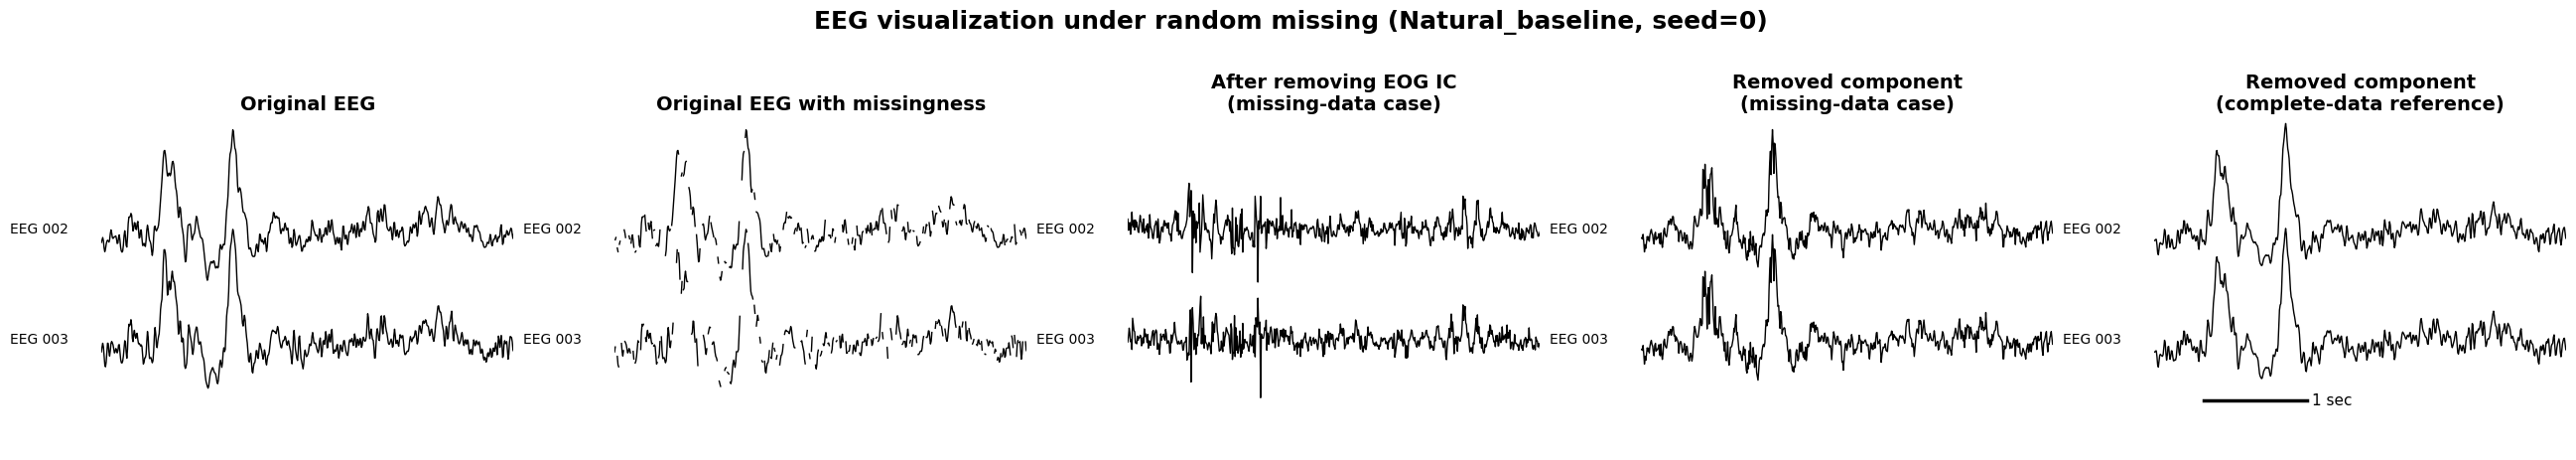

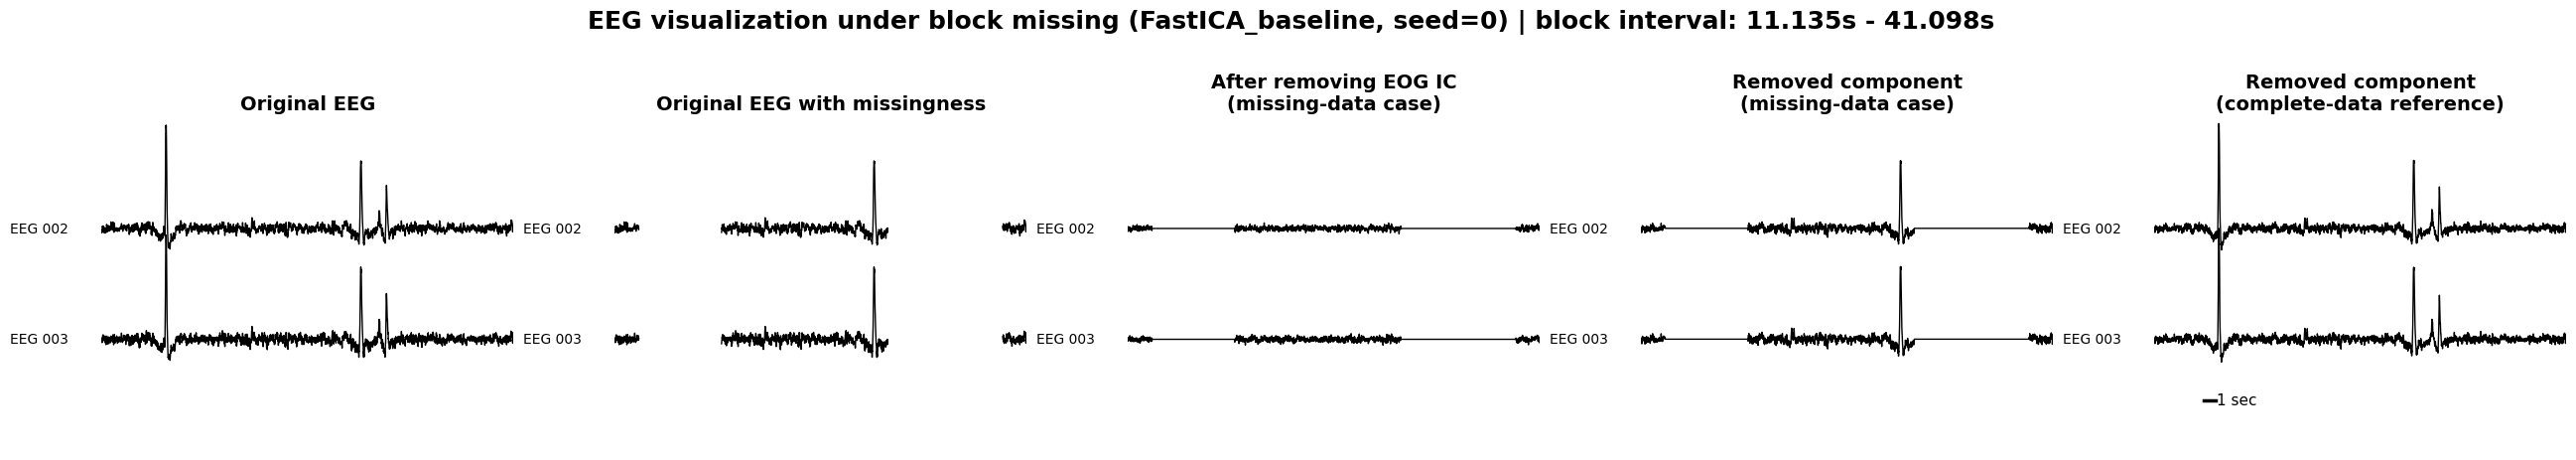

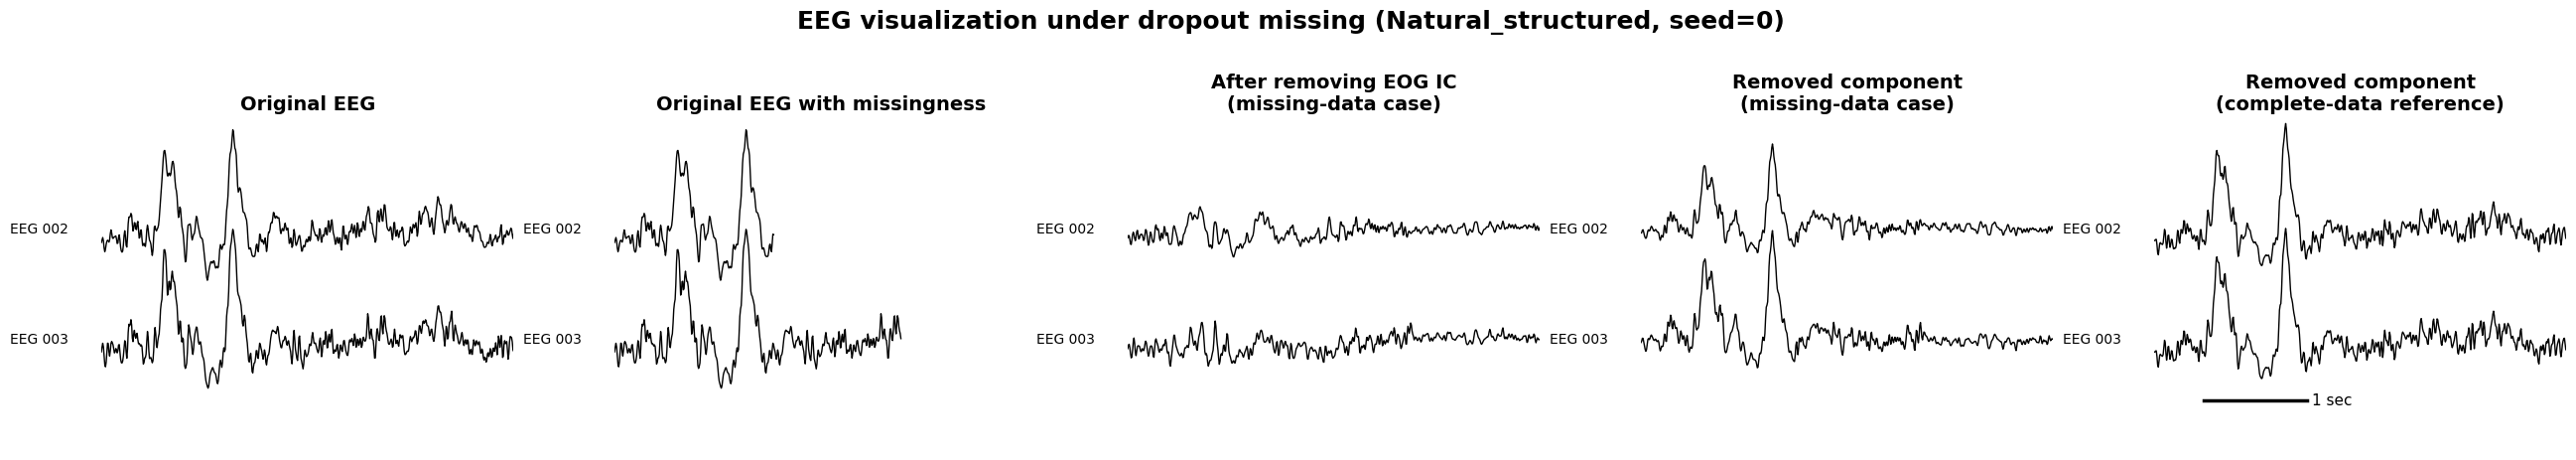

In [ ]:
# =========================
# EEG visualization for the best method of each pattern
# 1) Original EEG
# 2) Original EEG with missingness
# 3) After removing EOG IC
# 4) Removed component (missing-data case)
# 5) Removed component (complete-data reference)
# =========================
import numpy as np, matplotlib.pyplot as plt

display_seed=0
channel_corrs=np.array([abs(_safe_corr(X_eeg[k],eog)) for k in range(X_eeg.shape[0])]); top_idx=np.argsort(channel_corrs)[::-1][:6]; top_names=[eeg_names[i] for i in top_idx]
Y_full=eeg_full_result.Y.copy(); W_full=eeg_full_result.W.copy(); Y_no_eog=Y_full.copy(); Y_no_eog[reference_eog_ic,:]=0.0
X_white_rec=np.linalg.pinv(W_full)@Y_no_eog; X_clean_complete=np.linalg.pinv(eeg_whitening)@X_white_rec+eeg_mean; X_removed_complete=X_eeg-X_clean_complete

def _panel(ax,X,ch_idx,ch_names,t,start,end,title,scale):
    offsets=np.arange(len(ch_idx),0,-1)
    for i,(idx,name) in enumerate(zip(ch_idx,ch_names)):
        sig=np.asarray(X[idx,start:end],dtype=float); y=sig/scale+offsets[i]
        ax.plot(t,y,color="black",linewidth=1.0); ax.text(t[0]-0.08*(t[-1]-t[0]),offsets[i],name,ha="right",va="center",fontsize=10)
    ax.set_title(title,fontsize=14,fontweight="bold"); ax.set_xlim(t[0],t[-1]); ax.set_ylim(0,len(ch_idx)+1); ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values(): spine.set_visible(False)

for pattern in PART2_PATTERNS:
    best_method=best_method_df.loc[best_method_df["Pattern"]==pattern,"Method"].iloc[0]
    case=[c for c in eeg_cases[pattern][display_seed] if c["method"]==best_method][0]
    M=case["M"]; X_missing=case["X_missing"]; X_clean_missing=case["X_clean"]; X_removed_missing=case["X_for_reconstruction"]-X_clean_missing

    if pattern=="block":
        missing_idx=np.where(M[0]==0)[0]; block_start,block_end=missing_idx[0],missing_idx[-1]; block_start_sec,block_end_sec=block_start/sfreq,block_end/sfreq
        start_sec=max(0,block_start_sec-2.0); end_sec=min(X_eeg.shape[1]/sfreq,block_end_sec+2.0); start,end=int(start_sec*sfreq),int(end_sec*sfreq)
    else:
        center=int(eeg_data["blink_samples"][2]) if "blink_samples" in eeg_data and len(eeg_data["blink_samples"])>0 else int(5.0*sfreq); half_w=int(2*sfreq); start,end=max(0,center-half_w),min(X_eeg.shape[1],center+half_w)

    t=np.arange(start,end)/sfreq; X_missing_vis=X_eeg.astype(float).copy(); X_missing_vis[M==0]=np.nan

    # 只展示前两行
    show_idx=top_idx[:2]; show_names=top_names[:2]

    scale=max(np.nanmax(np.abs(X_eeg[show_idx,start:end])),np.nanmax(np.abs(X_missing_vis[show_idx,start:end])),np.nanmax(np.abs(X_clean_missing[show_idx,start:end])),np.nanmax(np.abs(X_removed_missing[show_idx,start:end])),np.nanmax(np.abs(X_removed_complete[show_idx,start:end])))+1e-8

    fig,axes=plt.subplots(1,5,figsize=(26,4.5))
    title=f"EEG visualization under {pattern} missing ({case['method']}, seed={display_seed})"
    if pattern=="block": title=f"EEG visualization under block missing ({case['method']}, seed={display_seed}) | block interval: {block_start_sec:.3f}s - {block_end_sec:.3f}s"
    fig.suptitle(title,fontsize=18,fontweight="bold",y=1.02)

    _panel(axes[0],X_eeg,show_idx,show_names,t,start,end,"Original EEG",scale)
    _panel(axes[1],X_missing_vis,show_idx,show_names,t,start,end,"Original EEG with missingness",scale)
    _panel(axes[2],X_clean_missing,show_idx,show_names,t,start,end,"After removing EOG IC\n(missing-data case)",scale)
    _panel(axes[3],X_removed_missing,show_idx,show_names,t,start,end,"Removed component\n(missing-data case)",scale)
    _panel(axes[4],X_removed_complete,show_idx,show_names,t,start,end,"Removed component\n(complete-data reference)",scale)

    x0=t[0]+0.12*(t[-1]-t[0]); x1=x0+1.0; ybar=0.45; axes[4].plot([x0,x1],[ybar,ybar],color="black",linewidth=2.5); axes[4].text(x1+0.05,ybar,"1 sec",va="center",fontsize=11)
    plt.tight_layout(); plt.show()

In [2]:
# =========================


| Missingness pattern | Low dimensions | Low alternative | High dimensions | High alternative |
|---------------------|----------------|-----------------|-----------------|------------------|
| Random missing      | Natural_structured | Natural_masked | Natural_structured | Natural_masked |
| Block missing       | FastICA_baseline | Natural_masked | FastICA_baseline | Natural_baseline |
| Dropout missing     | FastICA_structured | Natural_structured | Natural_structured | Natural_baseline |

The synthetic and EEG results share a common pattern: the missingness structure has a stronger impact on method performance than the dimension alone. In particular, random-like missingness tends to favor Natural-gradient-based approaches, while block missingness is better handled by methods with stronger structural preprocessing or more stable global separation behavior.

However, the synthetic experiments produce sharper conclusions, with masked Natural Gradient clearly dominating under random and dropout missingness, whereas the EEG results are more nuanced and often favor structured or even baseline variants. This difference is expected because the synthetic task evaluates global separation quality through the Amari index, while the EEG task focuses on recovering a specific reference component. Therefore, a method that is optimal for overall blind source separation is not necessarily the best for reference-IC recovery on real physiological signals.

In short, synthetic mixtures mainly reflect how well a method matches the assumed ICA model under controlled missingness, whereas EEG data additionally require robustness to noise, nonstationarity, and preservation of meaningful temporal structure.

<a id="Conclusion"></a>

## Conclusion

This final notebook provides a complete, directly runnable project pipeline.

### Main scientific conclusions to verify after execution

1. **Part 1:** the complete-data ICA benchmark identifies how solver quality and runtime evolve from low dimension to high dimension.
2. **Part 2:** the best ICA strategy under missing data can depend strongly on the missingness pattern.
3. **EEG transfer:** synthetic rankings can partially transfer to real artifact-removal tasks, but the agreement may weaken when the real-data objective differs from exact source recovery.


